# BD-TrafficGuard — Robust Bangladeshi Traffic Sign Detection & Recognition

This notebook implements the project requirements from the supplied proposal and presentation:

- Bangladesh Road Traffic Sign Dataset: detection with 31 classes
- clean train/validation/test split
- YOLO baseline
- degradation-aware robust YOLO
- controlled corruption benchmark: Gaussian blur, motion blur, low light, glare, fog, rain, occlusion, JPEG compression, small-object/resolution degradation
- clean vs corrupted evaluation
- mAP@0.5, mAP@0.5:0.95, precision, recall, F1
- robustness drop
- class-wise analysis
- inference time / FPS / model size
- ablation experiments
- qualitative failure analysis
- optional Faster R-CNN comparison
- optional two-stage detector + classifier using EfficientNet-B0
- export for lightweight deployment

**Important:** set `DATASET_SOURCE` in Cell 2 to your downloaded dataset location. The notebook is designed to work with a YOLO-format dataset or with a dataset that already contains image/annotation folders that can be converted.

In [7]:
# ============================================================
# KAGGLE ENVIRONMENT FIX
# Run this cell FIRST, then restart the Kaggle session/kernel.
# ============================================================

%pip install -q --force-reinstall --no-cache-dir \
    "numpy==2.2.6" \
    "scipy==1.15.3" \
    "pandas==2.2.3" \
    "seaborn==0.13.2" \
    "scikit-learn==1.6.1"

%pip install -q -U ultralytics pyyaml tqdm

# ============================================================
# 1. IMPORTS — KAGGLE
# ============================================================

import os
import sys
import json
import time
import math
import random
import shutil
import zipfile
import warnings
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageEnhance, ImageFilter
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

import torch
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from ultralytics import YOLO

warnings.filterwarnings("ignore")


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 3. DEVICE
# ============================================================

DEVICE = 0 if torch.cuda.is_available() else "cpu"


# ============================================================
# 4. ENVIRONMENT INFORMATION
# ============================================================

print("=" * 60)
print("BD-TrafficGuard — Kaggle Environment")
print("=" * 60)

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("SciPy       :", __import__("scipy").__version__)
print("Seaborn     :", sns.__version__)
print("Scikit-learn:", __import__("sklearn").__version__)
print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("Ultralytics :", __import__("ultralytics").__version__)
print("CUDA        :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
    print(
        "GPU Memory  :",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

print("Device      :", DEVICE)

print("=" * 60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 156.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 80.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 246.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.0/125.0 kB 266.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 277.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 264.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 263.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 229.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 256.6 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 320.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 265.6 MB/s eta 0:00:00 

In [8]:
# ============================================================
# 2. PROJECT CONFIGURATION — KAGGLE
# ============================================================

from pathlib import Path
import yaml
import os
import torch


# ============================================================
# KAGGLE DATASET
# ============================================================
# Your Kaggle dataset structure:
#
# /kaggle/input/
# └── Bdro﻿adTraffic_Zenodo/
#     └── Annotated Images Without Augme/
#         ├── train/
#         │   ├── images/
#         │   └── labels/
#         ├── valid/
#         │   ├── images/
#         │   └── labels/
#         ├── test/
#         │   ├── images/
#         │   └── labels/
#         └── data.yaml
#
# IMPORTANT:
# We preserve the official train/valid/test split.
# We do NOT create a new random 80/10/10 split.


KAGGLE_INPUT = Path("/kaggle/input")

# Automatically find data.yaml instead of hard-coding the
# potentially truncated Kaggle folder name.
yaml_candidates = list(KAGGLE_INPUT.rglob("data.yaml"))

if not yaml_candidates:
    raise FileNotFoundError(
        "Could not find data.yaml under /kaggle/input/. "
        "Please check that the BD Traffic Sign dataset is attached."
    )

DATA_YAML = yaml_candidates[0]

# Dataset root = folder containing data.yaml
DATASET_ROOT = DATA_YAML.parent


print("=" * 70)
print("DATASET CONFIGURATION")
print("=" * 70)

print("Dataset root:")
print(DATASET_ROOT)

print("\ndata.yaml:")
print(DATA_YAML)


# ============================================================
# VERIFY DATASET STRUCTURE
# ============================================================

REQUIRED_DIRS = [
    DATASET_ROOT / "train" / "images",
    DATASET_ROOT / "train" / "labels",
    DATASET_ROOT / "valid" / "images",
    DATASET_ROOT / "valid" / "labels",
    DATASET_ROOT / "test" / "images",
    DATASET_ROOT / "test" / "labels",
]

print("\nChecking required directories...")

for directory in REQUIRED_DIRS:
    if directory.exists():
        print(f"✓ {directory}")
    else:
        print(f"✗ MISSING: {directory}")


# ============================================================
# READ data.yaml
# ============================================================

with open(DATA_YAML, "r") as f:
    DATA_CONFIG = yaml.safe_load(f)

print("\n" + "=" * 70)
print("DATA.YAML")
print("=" * 70)

print(yaml.dump(DATA_CONFIG, sort_keys=False))


# ============================================================
# CLASS INFORMATION
# ============================================================

NUM_CLASSES = DATA_CONFIG.get("nc", None)
CLASS_NAMES = DATA_CONFIG.get("names", None)

# Some Roboflow YAML files don't explicitly contain `nc`.
# In that case infer it from names.
if NUM_CLASSES is None and CLASS_NAMES is not None:
    NUM_CLASSES = len(CLASS_NAMES)

if CLASS_NAMES is None:
    raise ValueError(
        "Could not find class names in data.yaml."
    )

print("=" * 70)
print("CLASS INFORMATION")
print("=" * 70)

print("Number of classes:", NUM_CLASSES)

for class_id, class_name in enumerate(CLASS_NAMES):
    print(f"{class_id:2d}: {class_name}")


# ============================================================
# DATASET SPLITS
# ============================================================

TRAIN_IMAGES = DATASET_ROOT / "train" / "images"
TRAIN_LABELS = DATASET_ROOT / "train" / "labels"

VAL_IMAGES = DATASET_ROOT / "valid" / "images"
VAL_LABELS = DATASET_ROOT / "valid" / "labels"

TEST_IMAGES = DATASET_ROOT / "test" / "images"
TEST_LABELS = DATASET_ROOT / "test" / "labels"


# ============================================================
# COUNT FILES
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


def count_images(directory):
    return sum(
        1
        for p in directory.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def count_labels(directory):
    return sum(
        1
        for p in directory.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    )


TRAIN_IMAGE_COUNT = count_images(TRAIN_IMAGES)
TRAIN_LABEL_COUNT = count_labels(TRAIN_LABELS)

VAL_IMAGE_COUNT = count_images(VAL_IMAGES)
VAL_LABEL_COUNT = count_labels(VAL_LABELS)

TEST_IMAGE_COUNT = count_images(TEST_IMAGES)
TEST_LABEL_COUNT = count_labels(TEST_LABELS)


print("\n" + "=" * 70)
print("DATASET SIZE")
print("=" * 70)

print(f"Train : {TRAIN_IMAGE_COUNT:,} images | {TRAIN_LABEL_COUNT:,} labels")
print(f"Valid : {VAL_IMAGE_COUNT:,} images | {VAL_LABEL_COUNT:,} labels")
print(f"Test  : {TEST_IMAGE_COUNT:,} images | {TEST_LABEL_COUNT:,} labels")

print(
    f"\nTotal images: "
    f"{TRAIN_IMAGE_COUNT + VAL_IMAGE_COUNT + TEST_IMAGE_COUNT:,}"
)


# ============================================================
# PROJECT OUTPUT DIRECTORIES
# ============================================================
# IMPORTANT:
# /kaggle/input is READ-ONLY.
# All generated files/models/results go to /kaggle/working.


PROJECT_ROOT = Path("/kaggle/working/BD-TrafficGuard")

RUNS_ROOT = PROJECT_ROOT / "runs"
CORRUPTION_ROOT = PROJECT_ROOT / "BD-TrafficSign-C"

RESULTS_ROOT = PROJECT_ROOT / "results"
MODELS_ROOT = PROJECT_ROOT / "models"
PLOTS_ROOT = PROJECT_ROOT / "plots"
PREDICTIONS_ROOT = PROJECT_ROOT / "predictions"
TABLES_ROOT = PROJECT_ROOT / "tables"


for directory in [
    PROJECT_ROOT,
    RUNS_ROOT,
    CORRUPTION_ROOT,
    RESULTS_ROOT,
    MODELS_ROOT,
    PLOTS_ROOT,
    PREDICTIONS_ROOT,
    TABLES_ROOT,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ============================================================
# EXPERIMENT SETTINGS
# ============================================================

IMG_SIZE = 640

EPOCHS_BASELINE = 50
EPOCHS_ROBUST = 50

BATCH_SIZE = 16
WORKERS = 2

# ------------------------------------------------------------
# Quick smoke test
# ------------------------------------------------------------
# Set True only when checking whether the entire pipeline works.
#
# For the real experiment:
# QUICK_TEST = False

QUICK_TEST = False

if QUICK_TEST:
    EPOCHS_BASELINE = 2
    EPOCHS_ROBUST = 2
    BATCH_SIZE = 4


# ============================================================
# MODELS
# ============================================================

YOLO_BASELINE = "yolo11n.pt"
YOLO_SMALL = "yolo11s.pt"


# ============================================================
# DEVICE
# ============================================================

DEVICE = 0 if torch.cuda.is_available() else "cpu"


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("BD-TRAFFICGUARD CONFIGURATION")
print("=" * 70)

print("Dataset       :", DATASET_ROOT)
print("data.yaml     :", DATA_YAML)

print("Classes       :", NUM_CLASSES)
print("Image size    :", IMG_SIZE)

print("Baseline      :", YOLO_BASELINE)
print("Small model   :", YOLO_SMALL)

print("Baseline epochs:", EPOCHS_BASELINE)
print("Robust epochs  :", EPOCHS_ROBUST)
print("Batch size     :", BATCH_SIZE)
print("Workers        :", WORKERS)

print("Device         :", DEVICE)

print("\nOutput directory:")
print(PROJECT_ROOT)

print("\n✓ Configuration complete.")

DATASET CONFIGURATION
Dataset root:
/kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation

data.yaml:
/kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/data.yaml

Checking required directories...
✓ /kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/train/images
✓ /kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/train/labels
✓ /kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/valid/images
✓ /kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/valid/labels
✓ /kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/test/images
✓ /kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/test/lab

## Dataset Validation & Class Distribution

BD-TRAFFICGUARD DATASET VALIDATION

[TRAIN]
Images          : 7,165
Labels          : 7,165
Missing labels  : 0
Orphan labels   : 0

[VALID]
Images          : 2,046
Labels          : 2,046
Missing labels  : 0
Orphan labels   : 0

[TEST]
Images          : 1,024
Labels          : 1,024
Missing labels  : 0
Orphan labels   : 0

YOLO LABEL VALIDATION


Checking train labels:   0%|          | 0/7165 [00:00<?, ?it/s]

Checking valid labels:   0%|          | 0/2046 [00:00<?, ?it/s]

Checking test labels:   0%|          | 0/1024 [00:00<?, ?it/s]


Total annotated objects: 10,296
Invalid label rows      : 0
Unreadable label files  : 0

CLASS DISTRIBUTION


...

,class_id,class_name,train,valid,test,total,train_pct,total_pct
0,0,Crossroads,435,138,62,635,6.035799,6.167444
1,1,Emergency Stopping,443,114,59,616,6.146802,5.982906
2,2,Emergency Stopping 250m,131,27,17,175,1.817677,1.699689
3,3,Give Way,124,40,14,178,1.720549,1.728827
4,4,Height Limit 5.7m,669,177,104,950,9.282642,9.226884
5,5,Hospital Ahead,6,5,3,14,0.083252,0.135975
6,6,Junction Ahead,39,7,2,48,0.541141,0.466200
7,7,Mosque Ahead,422,99,66,587,5.855418,5.701243
8,8,No Overtaking,367,113,56,536,5.092271,5.205905
9,9,No Pedestrians,60,12,9,81,0.832524,0.786713



SUMMARY
Train : 7,165 images | 7,207 annotated objects
Valid : 2,046 images | 2,064 annotated objects
Test  : 1,024 images | 1,025 annotated objects

Most represented classes:


,class_id,class_name,total
17,17,Side Road On Right,1109
4,4,Height Limit 5.7m,950
16,16,Side Road On Left,853
0,0,Crossroads,635
11,11,Pedestrians Crossing,631
12,12,Petrol Pump Ahead,617
1,1,Emergency Stopping,616
7,7,Mosque Ahead,587
20,20,Speed Limit 40Km,561
8,8,No Overtaking,536



Least represented classes:


,class_id,class_name,total
30,30,Weight Limit 27T,0
29,29,Weight Limit 10T,0
5,5,Hospital Ahead,14
25,25,Traffic Merges From Right,22
6,6,Junction Ahead,48
23,23,Tolls Ahead,56
19,19,Speed Limit 20 km,66
22,22,Tolls 1 km Ahead,66
27,27,U Turn,75
9,9,No Pedestrians,81


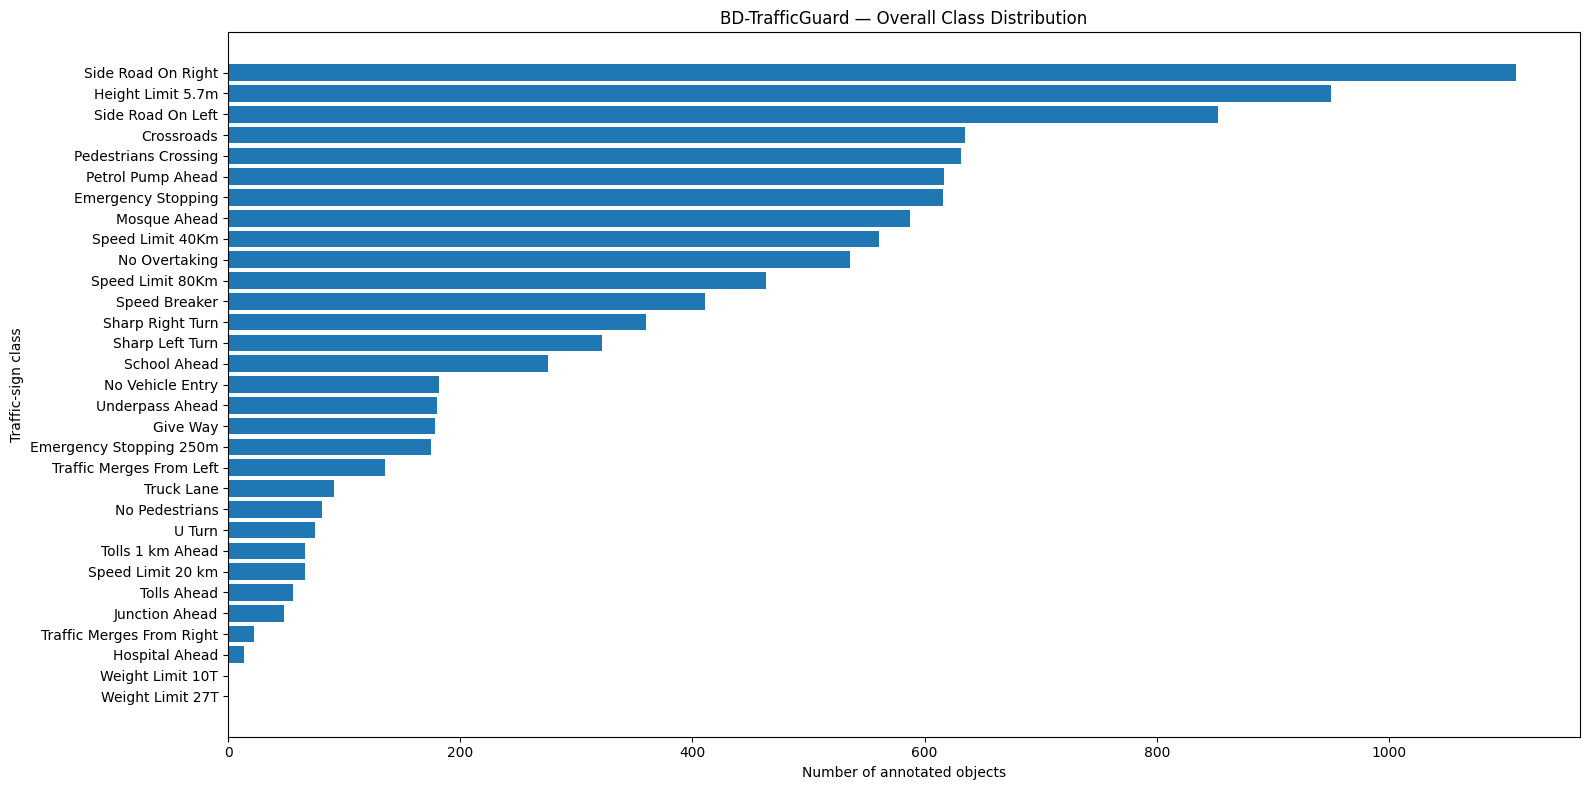


Saved:
/kaggle/working/BD-TrafficGuard/tables/class_distribution.csv

✓ DATASET VALIDATION PASSED


In [9]:
# ============================================================
# 3. DATASET VALIDATION & CLASS DISTRIBUTION
# ============================================================

from collections import Counter

print("=" * 70)
print("BD-TRAFFICGUARD DATASET VALIDATION")
print("=" * 70)


# ============================================================
# 1. CHECK IMAGE ↔ LABEL MATCHING
# ============================================================

def get_image_stem_set(directory):
    return {
        p.stem
        for p in directory.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    }


def get_label_stem_set(directory):
    return {
        p.stem
        for p in directory.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    }


splits = {
    "train": (TRAIN_IMAGES, TRAIN_LABELS),
    "valid": (VAL_IMAGES, VAL_LABELS),
    "test": (TEST_IMAGES, TEST_LABELS),
}

matching_summary = {}

for split_name, (image_dir, label_dir) in splits.items():

    image_stems = get_image_stem_set(image_dir)
    label_stems = get_label_stem_set(label_dir)

    missing_labels = image_stems - label_stems
    orphan_labels = label_stems - image_stems

    matching_summary[split_name] = {
        "images": len(image_stems),
        "labels": len(label_stems),
        "missing_labels": len(missing_labels),
        "orphan_labels": len(orphan_labels),
    }

    print(f"\n[{split_name.upper()}]")
    print(f"Images          : {len(image_stems):,}")
    print(f"Labels          : {len(label_stems):,}")
    print(f"Missing labels  : {len(missing_labels):,}")
    print(f"Orphan labels   : {len(orphan_labels):,}")

    if missing_labels:
        print("  Example missing labels:", list(missing_labels)[:5])

    if orphan_labels:
        print("  Example orphan labels:", list(orphan_labels)[:5])


# ============================================================
# 2. VALIDATE YOLO LABEL FORMAT
# ============================================================

print("\n" + "=" * 70)
print("YOLO LABEL VALIDATION")
print("=" * 70)

invalid_files = []
invalid_rows = []

total_objects = 0

for split_name, (_, label_dir) in splits.items():

    label_files = list(label_dir.glob("*.txt"))

    for label_file in tqdm(
        label_files,
        desc=f"Checking {split_name} labels"
    ):

        try:
            with open(label_file, "r") as f:
                lines = [line.strip() for line in f if line.strip()]

            for line_number, line in enumerate(lines, start=1):

                parts = line.split()

                # YOLO detection format:
                # class_id x_center y_center width height
                if len(parts) != 5:
                    invalid_rows.append({
                        "file": str(label_file),
                        "line": line_number,
                        "reason": "Expected 5 values",
                        "content": line,
                    })
                    continue

                try:
                    class_id = int(parts[0])
                    x, y, w, h = map(float, parts[1:])
                except ValueError:
                    invalid_rows.append({
                        "file": str(label_file),
                        "line": line_number,
                        "reason": "Non-numeric value",
                        "content": line,
                    })
                    continue

                # Class ID check
                if not (0 <= class_id < NUM_CLASSES):
                    invalid_rows.append({
                        "file": str(label_file),
                        "line": line_number,
                        "reason": f"Invalid class ID: {class_id}",
                        "content": line,
                    })
                    continue

                # Bounding box values must be normalized [0,1]
                bbox_values = [x, y, w, h]

                if not all(0 <= v <= 1 for v in bbox_values):
                    invalid_rows.append({
                        "file": str(label_file),
                        "line": line_number,
                        "reason": "Bounding box outside [0,1]",
                        "content": line,
                    })
                    continue

                # Width and height must be > 0
                if w <= 0 or h <= 0:
                    invalid_rows.append({
                        "file": str(label_file),
                        "line": line_number,
                        "reason": "Zero/negative width or height",
                        "content": line,
                    })
                    continue

                total_objects += 1

        except Exception as e:

            invalid_files.append({
                "file": str(label_file),
                "error": str(e),
            })


print("\nTotal annotated objects:", f"{total_objects:,}")
print("Invalid label rows      :", f"{len(invalid_rows):,}")
print("Unreadable label files  :", f"{len(invalid_files):,}")


# ============================================================
# 3. CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

class_counts = {
    "train": Counter(),
    "valid": Counter(),
    "test": Counter(),
}

object_counts_per_split = {}

for split_name, (_, label_dir) in splits.items():

    counter = Counter()

    for label_file in tqdm(
        label_dir.glob("*.txt"),
        desc=f"Counting {split_name} classes"
    ):

        with open(label_file, "r") as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                if len(parts) != 5:
                    continue

                try:
                    class_id = int(parts[0])
                except ValueError:
                    continue

                if 0 <= class_id < NUM_CLASSES:
                    counter[class_id] += 1

    class_counts[split_name] = counter

    object_counts_per_split[split_name] = sum(counter.values())


# ============================================================
# 4. CREATE DISTRIBUTION TABLE
# ============================================================

distribution_df = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": CLASS_NAMES,
    "train": [
        class_counts["train"][i]
        for i in range(NUM_CLASSES)
    ],
    "valid": [
        class_counts["valid"][i]
        for i in range(NUM_CLASSES)
    ],
    "test": [
        class_counts["test"][i]
        for i in range(NUM_CLASSES)
    ],
})

distribution_df["total"] = (
    distribution_df["train"]
    + distribution_df["valid"]
    + distribution_df["test"]
)

distribution_df["train_pct"] = (
    distribution_df["train"]
    / distribution_df["train"].sum()
    * 100
)

distribution_df["total_pct"] = (
    distribution_df["total"]
    / distribution_df["total"].sum()
    * 100
)

display(distribution_df)


# ============================================================
# 5. SUMMARY STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

for split_name in ["train", "valid", "test"]:

    num_images = matching_summary[split_name]["images"]
    num_objects = object_counts_per_split[split_name]

    print(
        f"{split_name.capitalize():6s}: "
        f"{num_images:,} images | "
        f"{num_objects:,} annotated objects"
    )


print("\nMost represented classes:")

display(
    distribution_df[
        ["class_id", "class_name", "total"]
    ]
    .sort_values("total", ascending=False)
    .head(10)
)


print("\nLeast represented classes:")

display(
    distribution_df[
        ["class_id", "class_name", "total"]
    ]
    .sort_values("total", ascending=True)
    .head(10)
)


# ============================================================
# 6. PLOT CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(16, 8))

plot_df = distribution_df.sort_values(
    "total",
    ascending=True
)

plt.barh(
    plot_df["class_name"],
    plot_df["total"]
)

plt.xlabel("Number of annotated objects")
plt.ylabel("Traffic-sign class")
plt.title("BD-TrafficGuard — Overall Class Distribution")

plt.tight_layout()
plt.show()


# ============================================================
# 7. SAVE DISTRIBUTION
# ============================================================

distribution_path = (
    TABLES_ROOT / "class_distribution.csv"
)

distribution_df.to_csv(
    distribution_path,
    index=False
)

print("\nSaved:")
print(distribution_path)


# ============================================================
# 8. FINAL VALIDATION STATUS
# ============================================================

print("\n" + "=" * 70)

if (
    len(invalid_rows) == 0
    and len(invalid_files) == 0
    and all(
        x["missing_labels"] == 0
        for x in matching_summary.values()
    )
):

    print("✓ DATASET VALIDATION PASSED")

else:

    print("⚠ DATASET VALIDATION FOUND ISSUES")

    if invalid_rows:
        print(
            f"  Invalid annotation rows: "
            f"{len(invalid_rows)}"
        )

    if invalid_files:
        print(
            f"  Unreadable label files: "
            f"{len(invalid_files)}"
        )

print("=" * 70)

## Visual Annotation Inspection

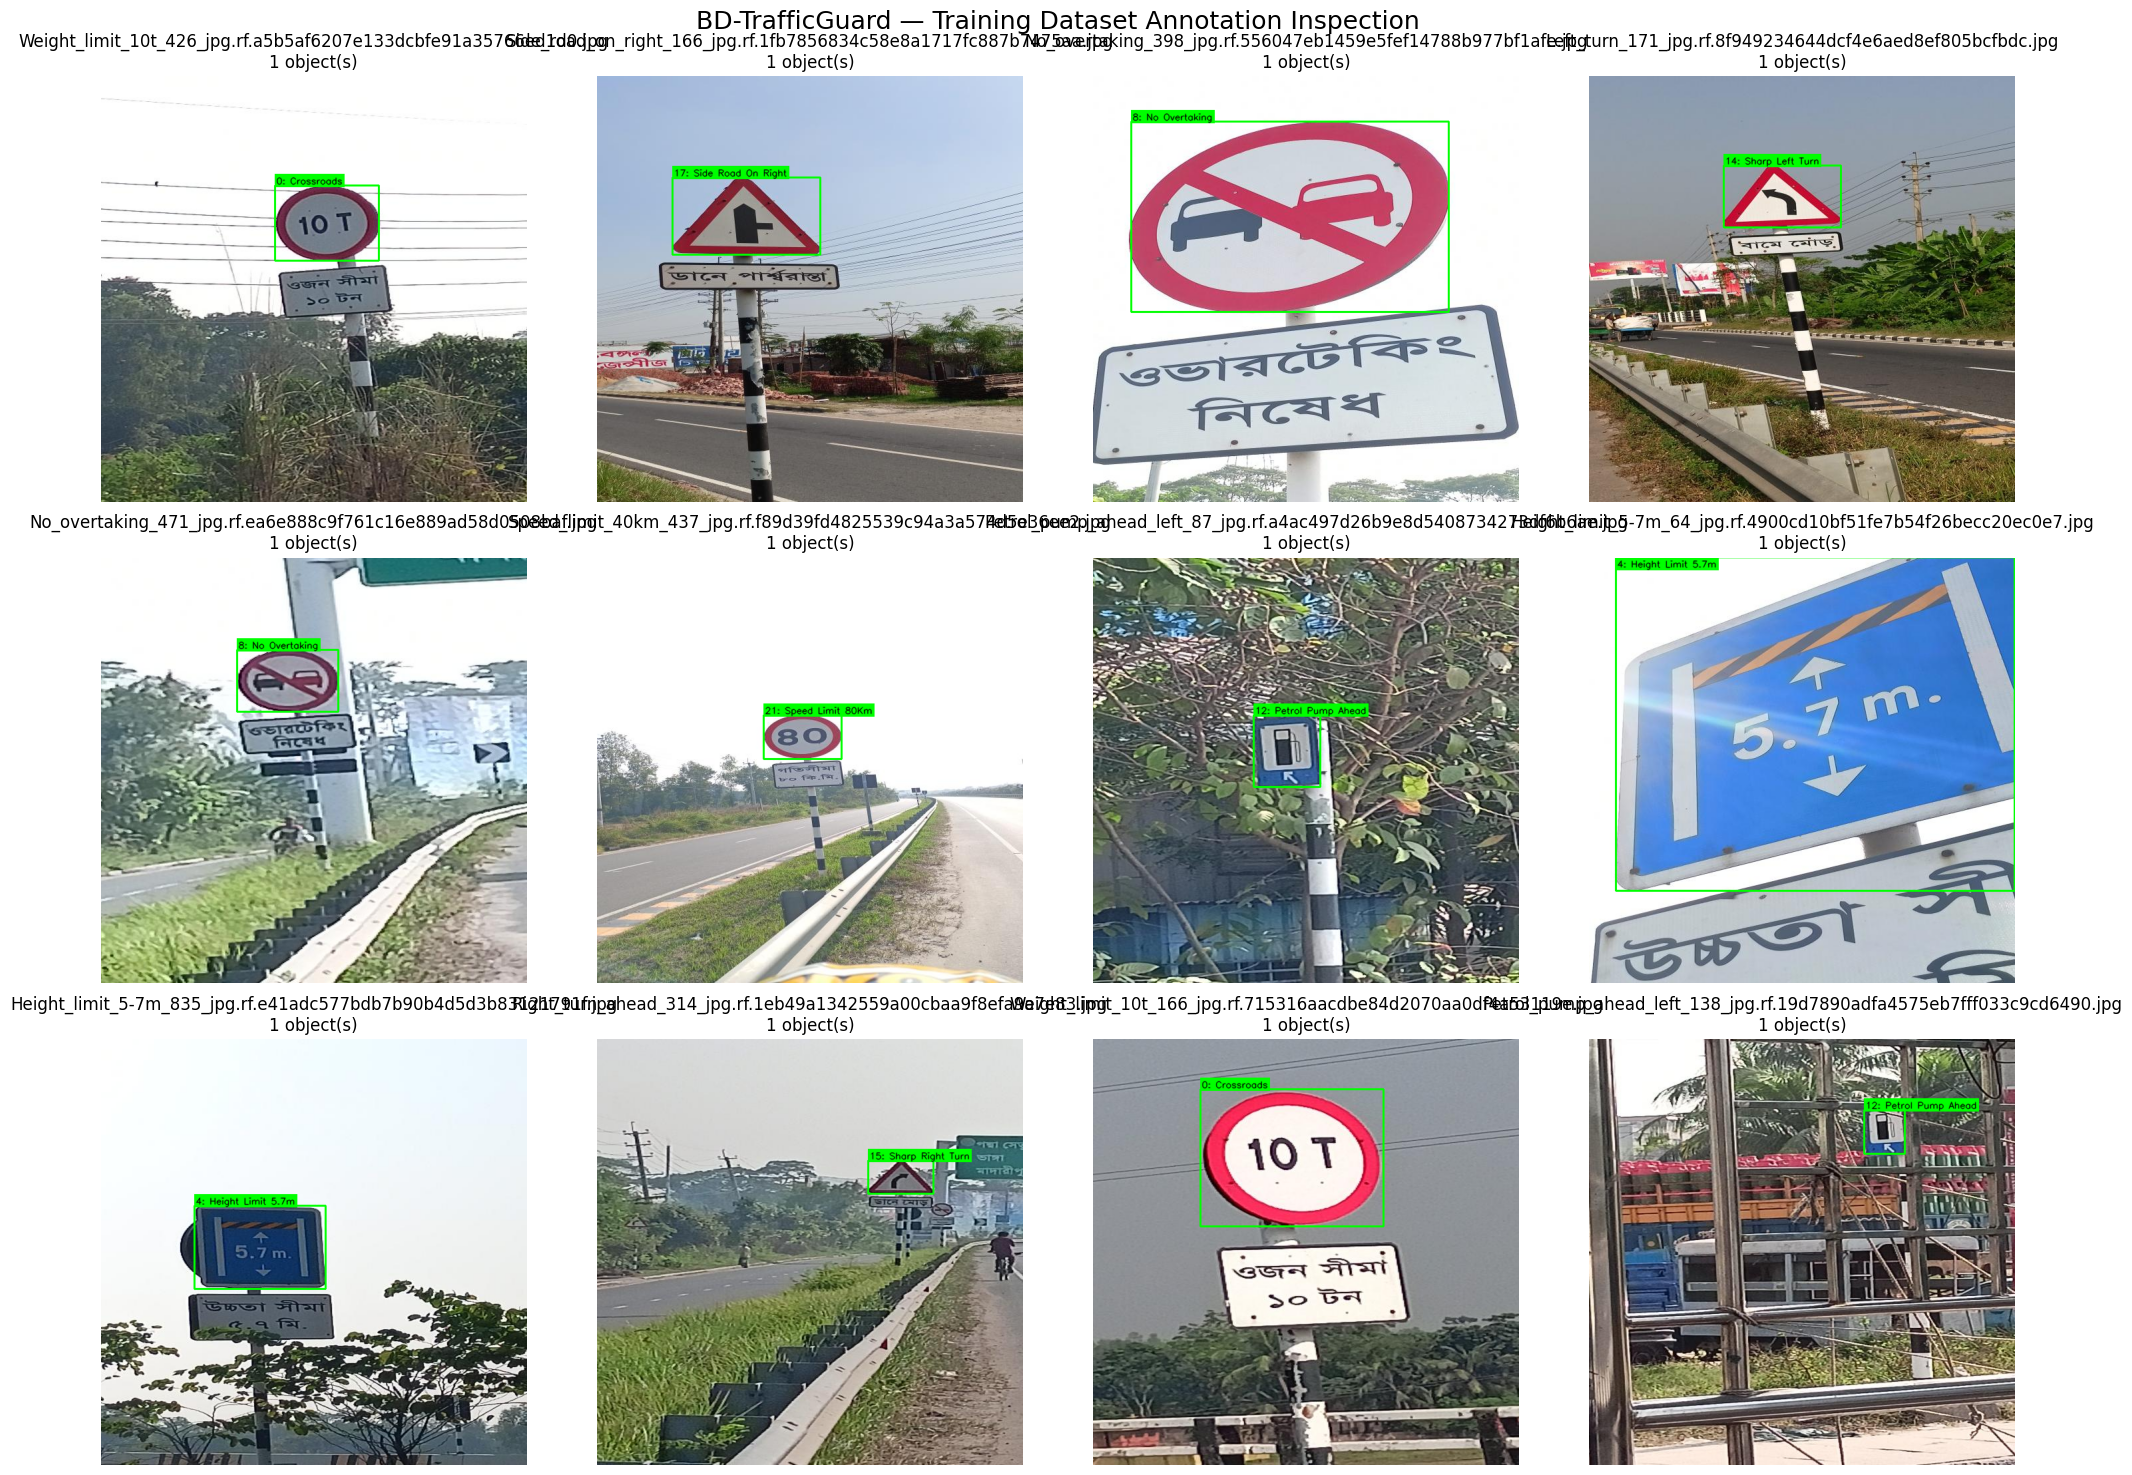

In [10]:
# ============================================================
# 4. VISUAL DATASET INSPECTION
# ============================================================

import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# CONFIGURATION
# ============================================================

NUM_SAMPLES = 12

random.seed(SEED)


# ============================================================
# HELPER: DRAW YOLO ANNOTATIONS
# ============================================================

def load_yolo_annotations(label_path):
    """
    Read YOLO-format annotations.

    Format:
        class_id x_center y_center width height

    Coordinates are normalized to [0, 1].
    """

    annotations = []

    if not label_path.exists():
        return annotations

    with open(label_path, "r") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            x_center, y_center, width, height = map(
                float,
                parts[1:]
            )

            annotations.append(
                (
                    class_id,
                    x_center,
                    y_center,
                    width,
                    height
                )
            )

    return annotations


def draw_yolo_boxes(image, annotations):
    """
    Draw YOLO bounding boxes and class names.
    """

    image = image.copy()

    height, width = image.shape[:2]

    for (
        class_id,
        x_center,
        y_center,
        box_width,
        box_height
    ) in annotations:

        # Convert normalized coordinates
        # to pixel coordinates.

        x1 = int(
            (x_center - box_width / 2) * width
        )

        y1 = int(
            (y_center - box_height / 2) * height
        )

        x2 = int(
            (x_center + box_width / 2) * width
        )

        y2 = int(
            (y_center + box_height / 2) * height
        )

        # Keep coordinates inside image.
        x1 = max(0, min(x1, width - 1))
        y1 = max(0, min(y1, height - 1))
        x2 = max(0, min(x2, width - 1))
        y2 = max(0, min(y2, height - 1))

        class_name = CLASS_NAMES[class_id]

        # Draw rectangle
        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Label
        label = f"{class_id}: {class_name}"

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.45
        thickness = 1

        (text_width, text_height), baseline = cv2.getTextSize(
            label,
            font,
            font_scale,
            thickness
        )

        text_y = max(
            y1,
            text_height + baseline + 2
        )

        # Background for text
        cv2.rectangle(
            image,
            (x1, text_y - text_height - baseline - 2),
            (
                x1 + text_width + 4,
                text_y + 2
            ),
            (0, 255, 0),
            -1
        )

        # Text
        cv2.putText(
            image,
            label,
            (x1 + 2, text_y - 2),
            font,
            font_scale,
            (0, 0, 0),
            thickness,
            cv2.LINE_AA
        )

    return image


# ============================================================
# GET RANDOM TRAINING IMAGES
# ============================================================

train_images = [
    p
    for p in TRAIN_IMAGES.iterdir()
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
]

if len(train_images) < NUM_SAMPLES:
    NUM_SAMPLES = len(train_images)

sample_images = random.sample(
    train_images,
    NUM_SAMPLES
)


# ============================================================
# DISPLAY
# ============================================================

fig, axes = plt.subplots(
    3,
    4,
    figsize=(20, 15)
)

axes = axes.flatten()

for ax, image_path in zip(
    axes,
    sample_images
):

    # Read image
    image = cv2.imread(
        str(image_path)
    )

    if image is None:
        ax.axis("off")
        continue

    # Convert BGR → RGB
    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Corresponding label
    label_path = TRAIN_LABELS / (
        image_path.stem + ".txt"
    )

    annotations = load_yolo_annotations(
        label_path
    )

    # Draw boxes
    annotated_image = draw_yolo_boxes(
        image,
        annotations
    )

    ax.imshow(annotated_image)

    ax.set_title(
        f"{image_path.name}\n"
        f"{len(annotations)} object(s)"
    )

    ax.axis("off")


# Hide unused axes
for ax in axes[len(sample_images):]:
    ax.axis("off")


plt.suptitle(
    "BD-TrafficGuard — Training Dataset Annotation Inspection",
    fontsize=18
)

plt.tight_layout()
plt.show()

## Dataset Statistics & Object-Size Analysis

BD-TRAFFICGUARD DATASET STATISTICS

IMAGE DIMENSIONS


Scanning images:   0%|          | 0/7165 [00:00<?, ?it/s]

Scanning images:   0%|          | 0/2046 [00:00<?, ?it/s]

Scanning images:   0%|          | 0/1024 [00:00<?, ?it/s]

,split,images,unique_widths,unique_heights,mean_width,mean_height,min_width,max_width,min_height,max_height,mean_aspect_ratio
0,train,7165,1,1,640.0,640.0,640,640,640,640,1.0
1,valid,2046,1,1,640.0,640.0,640,640,640,640,1.0
2,test,1024,1,1,640.0,640.0,640,640,640,640,1.0


...

,split,objects,mean_box_width,median_box_width,mean_box_height,median_box_height,mean_area_ratio,median_area_ratio,mean_aspect_ratio,median_aspect_ratio
0,test,1025,223.027317,172.0,141.928293,111.5,0.109094,0.045846,1.590264,1.626506
1,train,7207,221.039129,175.5,139.044054,113.0,0.104228,0.048537,1.596725,1.639594
2,valid,2064,214.035853,172.5,134.395833,110.5,0.097702,0.045859,1.601276,1.640055



Object-size distribution:


,size_category,objects,percentage
0,Small (<1%),968,9.401709
1,Medium (1%-5%),4360,42.346542
2,Large (>5%),4968,48.251748



OBJECTS PER IMAGE


,split,count,mean,median,min,max
0,test,1024,1.000977,1.0,0,2
1,train,7165,1.005862,1.0,0,3
2,valid,2046,1.008798,1.0,0,3


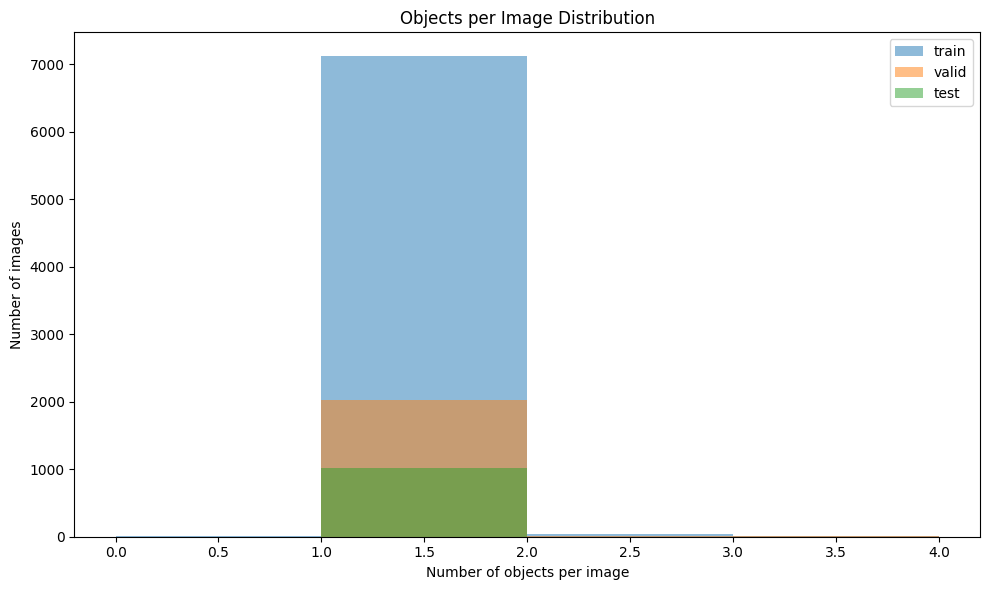

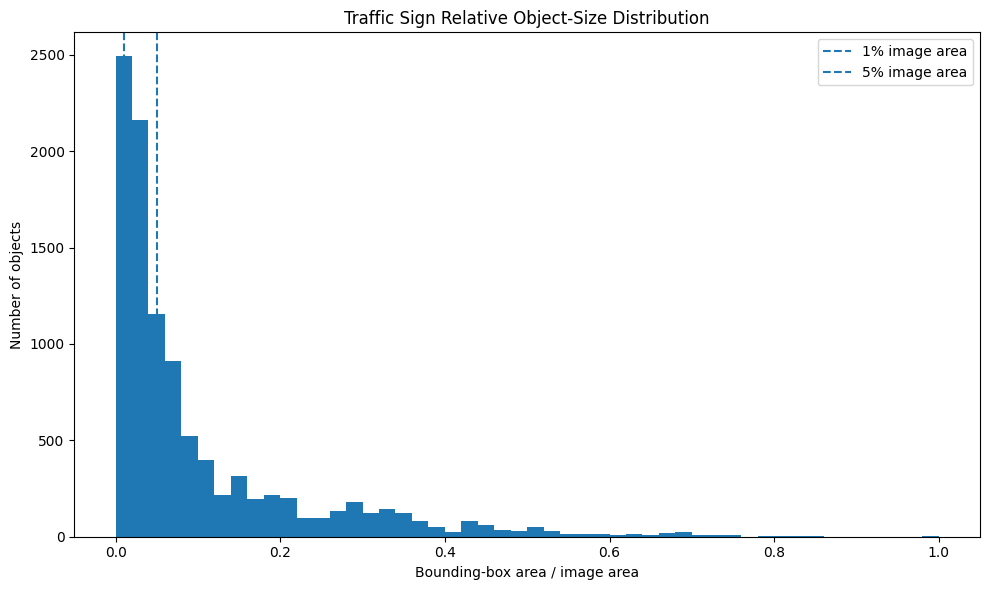

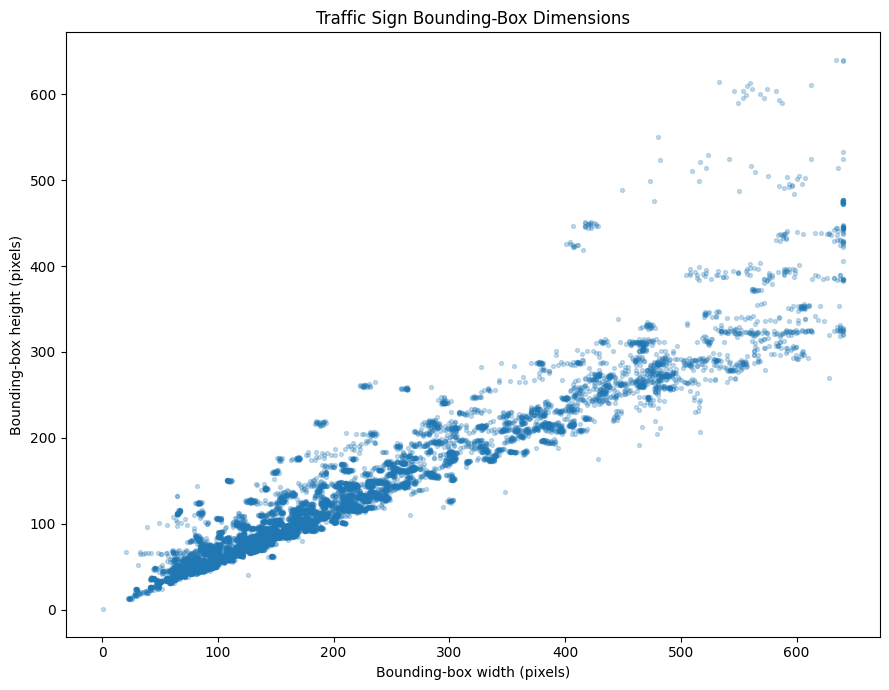


STATISTICS SAVED
Output directory: /kaggle/working/BD-TrafficGuard/tables


In [11]:
# ============================================================
# 5. DATASET STATISTICS & OBJECT-SIZE ANALYSIS
# ============================================================

from collections import Counter
from PIL import Image

print("=" * 70)
print("BD-TRAFFICGUARD DATASET STATISTICS")
print("=" * 70)


# ============================================================
# CONFIGURATION
# ============================================================

MAX_IMAGES_FOR_DIMENSION_SCAN = None
# None = scan all images
#
# If this is too slow, you can use:
# MAX_IMAGES_FOR_DIMENSION_SCAN = 2000


# ============================================================
# 1. IMAGE DIMENSIONS
# ============================================================

print("\n" + "=" * 70)
print("IMAGE DIMENSIONS")
print("=" * 70)


def collect_image_dimensions(image_dir, max_images=None):

    image_files = [
        p for p in image_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if max_images is not None:
        image_files = image_files[:max_images]

    dimensions = []

    for image_path in tqdm(
        image_files,
        desc=f"Scanning {image_dir.name}"
    ):

        try:
            with Image.open(image_path) as img:
                width, height = img.size

            dimensions.append({
                "file": image_path.name,
                "width": width,
                "height": height,
                "aspect_ratio": width / height
            })

        except Exception as e:
            print(
                f"Could not read {image_path}: {e}"
            )

    return pd.DataFrame(dimensions)


dimension_dfs = {}

for split_name, image_dir in [
    ("train", TRAIN_IMAGES),
    ("valid", VAL_IMAGES),
    ("test", TEST_IMAGES)
]:

    dimension_dfs[split_name] = collect_image_dimensions(
        image_dir,
        MAX_IMAGES_FOR_DIMENSION_SCAN
    )


# ============================================================
# DIMENSION SUMMARY
# ============================================================

dimension_summary = []

for split_name, df in dimension_dfs.items():

    dimension_summary.append({
        "split": split_name,
        "images": len(df),
        "unique_widths": df["width"].nunique(),
        "unique_heights": df["height"].nunique(),
        "mean_width": df["width"].mean(),
        "mean_height": df["height"].mean(),
        "min_width": df["width"].min(),
        "max_width": df["width"].max(),
        "min_height": df["height"].min(),
        "max_height": df["height"].max(),
        "mean_aspect_ratio": df["aspect_ratio"].mean()
    })


dimension_summary_df = pd.DataFrame(
    dimension_summary
)

display(dimension_summary_df)


# ============================================================
# MOST COMMON IMAGE RESOLUTIONS
# ============================================================

all_dimensions = pd.concat(
    dimension_dfs.values(),
    ignore_index=True
)

resolution_counts = (
    all_dimensions
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nMost common image resolutions:")

display(
    resolution_counts.head(15)
)


# ============================================================
# 2. OBJECT STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("BOUNDING-BOX STATISTICS")
print("=" * 70)


object_records = []

for split_name, (image_dir, label_dir) in splits.items():

    image_files = [
        p for p in image_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for image_path in tqdm(
        image_files,
        desc=f"Analyzing {split_name} objects"
    ):

        label_path = label_dir / (
            image_path.stem + ".txt"
        )

        if not label_path.exists():
            continue

        # Read image dimensions
        try:
            with Image.open(image_path) as img:
                image_width, image_height = img.size
        except:
            continue

        with open(label_path, "r") as f:
            lines = [
                line.strip()
                for line in f
                if line.strip()
            ]

        for line in lines:

            parts = line.split()

            if len(parts) != 5:
                continue

            try:
                class_id = int(parts[0])
                xc, yc, bw, bh = map(
                    float,
                    parts[1:]
                )
            except:
                continue

            # Convert normalized bbox to pixel dimensions
            box_width = bw * image_width
            box_height = bh * image_height

            box_area = (
                box_width *
                box_height
            )

            image_area = (
                image_width *
                image_height
            )

            area_ratio = (
                box_area /
                image_area
            )

            object_records.append({

                "split": split_name,

                "class_id": class_id,

                "class_name": (
                    CLASS_NAMES[class_id]
                    if 0 <= class_id < NUM_CLASSES
                    else "Unknown"
                ),

                "image_width": image_width,

                "image_height": image_height,

                "box_width": box_width,

                "box_height": box_height,

                "box_area": box_area,

                "box_area_ratio": area_ratio,

                "box_aspect_ratio": (
                    box_width / box_height
                    if box_height > 0
                    else np.nan
                )
            })


objects_df = pd.DataFrame(
    object_records
)

print(
    "Total objects analyzed:",
    f"{len(objects_df):,}"
)


# ============================================================
# 3. OBJECT SIZE SUMMARY
# ============================================================

object_summary = (
    objects_df
    .groupby("split")
    .agg(
        objects=("class_id", "count"),

        mean_box_width=("box_width", "mean"),
        median_box_width=("box_width", "median"),

        mean_box_height=("box_height", "mean"),
        median_box_height=("box_height", "median"),

        mean_area_ratio=("box_area_ratio", "mean"),
        median_area_ratio=("box_area_ratio", "median"),

        mean_aspect_ratio=("box_aspect_ratio", "mean"),
        median_aspect_ratio=("box_aspect_ratio", "median")
    )
    .reset_index()
)

display(object_summary)


# ============================================================
# 4. SMALL OBJECT ANALYSIS
# ============================================================
# We define object size by bounding-box area relative to
# the complete image.
#
# These thresholds are descriptive, not training rules.

SMALL_THRESHOLD = 0.01
MEDIUM_THRESHOLD = 0.05

objects_df["size_category"] = pd.cut(
    objects_df["box_area_ratio"],
    bins=[
        -np.inf,
        SMALL_THRESHOLD,
        MEDIUM_THRESHOLD,
        np.inf
    ],
    labels=[
        "Small (<1%)",
        "Medium (1%-5%)",
        "Large (>5%)"
    ]
)


size_distribution = (
    objects_df["size_category"]
    .value_counts()
    .reindex([
        "Small (<1%)",
        "Medium (1%-5%)",
        "Large (>5%)"
    ])
    .fillna(0)
    .astype(int)
    .reset_index()
)

size_distribution.columns = [
    "size_category",
    "objects"
]

size_distribution["percentage"] = (
    size_distribution["objects"]
    / size_distribution["objects"].sum()
    * 100
)

print("\nObject-size distribution:")

display(size_distribution)


# ============================================================
# 5. OBJECTS PER IMAGE
# ============================================================

print("\n" + "=" * 70)
print("OBJECTS PER IMAGE")
print("=" * 70)


objects_per_image = []

for split_name, (_, label_dir) in splits.items():

    for label_path in label_dir.glob("*.txt"):

        try:
            with open(label_path, "r") as f:
                count = sum(
                    1
                    for line in f
                    if line.strip()
                )

            objects_per_image.append({
                "split": split_name,
                "image": label_path.stem,
                "objects": count
            })

        except:
            pass


objects_per_image_df = pd.DataFrame(
    objects_per_image
)


objects_per_image_summary = (
    objects_per_image_df
    .groupby("split")
    ["objects"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
    .reset_index()
)

display(objects_per_image_summary)


# ============================================================
# 6. OBJECTS PER IMAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

for split_name in ["train", "valid", "test"]:

    values = objects_per_image_df[
        objects_per_image_df["split"] == split_name
    ]["objects"]

    plt.hist(
        values,
        bins=range(
            int(values.min()),
            int(values.max()) + 2
        ),
        alpha=0.5,
        label=split_name
    )

plt.xlabel("Number of objects per image")
plt.ylabel("Number of images")
plt.title(
    "Objects per Image Distribution"
)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 7. OBJECT SIZE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    objects_df["box_area_ratio"],
    bins=50
)

plt.axvline(
    SMALL_THRESHOLD,
    linestyle="--",
    label="1% image area"
)

plt.axvline(
    MEDIUM_THRESHOLD,
    linestyle="--",
    label="5% image area"
)

plt.xlabel(
    "Bounding-box area / image area"
)

plt.ylabel("Number of objects")

plt.title(
    "Traffic Sign Relative Object-Size Distribution"
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 8. BOX WIDTH VS HEIGHT
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    objects_df["box_width"],
    objects_df["box_height"],
    alpha=0.25,
    s=8
)

plt.xlabel("Bounding-box width (pixels)")
plt.ylabel("Bounding-box height (pixels)")

plt.title(
    "Traffic Sign Bounding-Box Dimensions"
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. SAVE STATISTICS
# ============================================================

objects_df.to_csv(
    TABLES_ROOT / "object_statistics.csv",
    index=False
)

dimension_summary_df.to_csv(
    TABLES_ROOT / "image_dimension_summary.csv",
    index=False
)

resolution_counts.to_csv(
    TABLES_ROOT / "image_resolution_distribution.csv",
    index=False
)

object_summary.to_csv(
    TABLES_ROOT / "object_size_summary.csv",
    index=False
)

size_distribution.to_csv(
    TABLES_ROOT / "object_size_distribution.csv",
    index=False
)

objects_per_image_summary.to_csv(
    TABLES_ROOT / "objects_per_image_summary.csv",
    index=False
)


print("\n" + "=" * 70)
print("STATISTICS SAVED")
print("=" * 70)

print(
    "Output directory:",
    TABLES_ROOT
)

## Train YOLO11n Baseline

In [12]:
# ============================================================
# 6. YOLO11n BASELINE TRAINING
# ============================================================

import os
import time
import json
import pandas as pd
from pathlib import Path
from ultralytics import YOLO

print("=" * 70)
print("BD-TRAFFICGUARD — YOLO11n BASELINE TRAINING")
print("=" * 70)

# ============================================================
# TRAINING CONFIGURATION
# ============================================================

BASELINE_RUN_NAME = "yolo11n_baseline"

BASELINE_PROJECT = RUNS_ROOT / "baseline"

BASELINE_PROJECT.mkdir(
    parents=True,
    exist_ok=True
)

print("Model       :", YOLO_BASELINE)
print("Dataset     :", DATA_YAML)
print("Image size  :", IMG_SIZE)
print("Epochs      :", EPOCHS_BASELINE)
print("Batch size  :", BATCH_SIZE)
print("Device      :", DEVICE)
print("Output      :", BASELINE_PROJECT)

# ============================================================
# LOAD PRETRAINED YOLO11n
# ============================================================

print("\nLoading YOLO11n...")

model_baseline = YOLO(YOLO_BASELINE)

print("✓ Model loaded")

# ============================================================
# TRAIN
# ============================================================

print("\n" + "=" * 70)
print("STARTING TRAINING")
print("=" * 70)

start_time = time.time()

baseline_results = model_baseline.train(
    
    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------
    data=str(DATA_YAML),
    
    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    epochs=EPOCHS_BASELINE,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    
    # --------------------------------------------------------
    # Hardware
    # --------------------------------------------------------
    device=DEVICE,
    workers=WORKERS,
    
    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------
    seed=SEED,
    
    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------
    project=str(BASELINE_PROJECT),
    name=BASELINE_RUN_NAME,
    
    # --------------------------------------------------------
    # Checkpointing
    # --------------------------------------------------------
    save=True,
    save_period=10,
    
    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    val=True,
    
    # --------------------------------------------------------
    # Plots / logging
    # --------------------------------------------------------
    plots=True,
    verbose=True,
    
    # --------------------------------------------------------
    # Pretrained model
    # --------------------------------------------------------
    pretrained=True,
    
    # --------------------------------------------------------
    # Keep the experiment reproducible
    # --------------------------------------------------------
    deterministic=True,
    
    # --------------------------------------------------------
    # Do not cache the entire dataset in RAM.
    # This is safer on Kaggle.
    # --------------------------------------------------------
    cache=False,
)

training_time = time.time() - start_time

print("\n" + "=" * 70)
print("BASELINE TRAINING COMPLETE")
print("=" * 70)

print(
    f"Training time: "
    f"{training_time / 60:.2f} minutes"
)


# ============================================================
# BEST CHECKPOINT
# ============================================================

BASELINE_RUN_DIR = (
    BASELINE_PROJECT /
    BASELINE_RUN_NAME
)

BASELINE_BEST = (
    BASELINE_RUN_DIR /
    "weights" /
    "best.pt"
)

BASELINE_LAST = (
    BASELINE_RUN_DIR /
    "weights" /
    "last.pt"
)

print("\nBest checkpoint:")
print(BASELINE_BEST)

print("\nLast checkpoint:")
print(BASELINE_LAST)

if BASELINE_BEST.exists():
    print("\n✓ best.pt exists")

else:
    raise FileNotFoundError(
        "best.pt was not created. "
        "Please inspect the training output."
    )


# ============================================================
# COPY BEST MODEL TO CENTRAL MODEL DIRECTORY
# ============================================================

CENTRAL_BASELINE_MODEL = (
    MODELS_ROOT /
    "yolo11n_baseline_best.pt"
)

import shutil

shutil.copy2(
    BASELINE_BEST,
    CENTRAL_BASELINE_MODEL
)

print("\nCentral model copy:")
print(CENTRAL_BASELINE_MODEL)


# ============================================================
# TRAINING SUMMARY
# ============================================================

training_summary = {
    "model": YOLO_BASELINE,
    "dataset": str(DATA_YAML),
    "num_classes": NUM_CLASSES,
    "train_images": TRAIN_IMAGE_COUNT,
    "valid_images": VAL_IMAGE_COUNT,
    "test_images": TEST_IMAGE_COUNT,
    "image_size": IMG_SIZE,
    "epochs": EPOCHS_BASELINE,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "training_time_seconds": training_time,
    "best_checkpoint": str(BASELINE_BEST),
}

with open(
    TABLES_ROOT / "baseline_training_config.json",
    "w"
) as f:
    json.dump(
        training_summary,
        f,
        indent=4
    )

print("\n✓ Training configuration saved.")

BD-TRAFFICGUARD — YOLO11n BASELINE TRAINING
Model       : yolo11n.pt
Dataset     : /kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/data.yaml
Image size  : 640
Epochs      : 50
Batch size  : 16
Device      : 0
Output      : /kaggle/working/BD-TrafficGuard/runs/baseline

Loading YOLO11n...
✓ Model loaded

STARTING TRAINING
Ultralytics 8.4.147 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, 

In [13]:
# ============================================================
# 7. YOLO11n BASELINE — CLEAN TEST EVALUATION
# ============================================================

from ultralytics import YOLO
import pandas as pd
import json
import numpy as np

print("=" * 70)
print("YOLO11n BASELINE — CLEAN TEST EVALUATION")
print("=" * 70)


# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

baseline_model = YOLO(
    str(CENTRAL_BASELINE_MODEL)
)

print("Loaded:")
print(CENTRAL_BASELINE_MODEL)


# ============================================================
# TEST EVALUATION
# ============================================================

print("\nEvaluating on official TEST split...")

test_start = time.time()

baseline_test_metrics = baseline_model.val(
    
    data=str(DATA_YAML),
    
    split="test",
    
    imgsz=IMG_SIZE,
    
    batch=BATCH_SIZE,
    
    device=DEVICE,
    
    workers=WORKERS,
    
    plots=True,
    
    save_json=True,
    
    verbose=True,
)

test_time = time.time() - test_start


# ============================================================
# EXTRACT OVERALL METRICS
# ============================================================

metrics_summary = {
    
    "model": "YOLO11n",
    
    "evaluation": "clean_test",
    
    "images": TEST_IMAGE_COUNT,
    
    "precision": float(
        baseline_test_metrics.box.mp
    ),
    
    "recall": float(
        baseline_test_metrics.box.mr
    ),
    
    "mAP50": float(
        baseline_test_metrics.box.map50
    ),
    
    "mAP50_95": float(
        baseline_test_metrics.box.map
    ),
    
    "test_evaluation_time_seconds": test_time,
}


# ============================================================
# DISPLAY
# ============================================================

print("\n" + "=" * 70)
print("CLEAN TEST RESULTS")
print("=" * 70)

print(
    f"Precision : "
    f"{metrics_summary['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{metrics_summary['recall']:.4f}"
)

print(
    f"mAP@50    : "
    f"{metrics_summary['mAP50']:.4f}"
)

print(
    f"mAP@50:95 : "
    f"{metrics_summary['mAP50_95']:.4f}"
)

print(
    f"Evaluation time: "
    f"{test_time:.2f} sec"
)


# ============================================================
# SAVE RESULTS
# ============================================================

baseline_metrics_df = pd.DataFrame(
    [metrics_summary]
)

baseline_metrics_path = (
    TABLES_ROOT /
    "yolo11n_baseline_clean_test.csv"
)

baseline_metrics_df.to_csv(
    baseline_metrics_path,
    index=False
)

with open(
    TABLES_ROOT /
    "yolo11n_baseline_clean_test.json",
    "w"
) as f:
    json.dump(
        metrics_summary,
        f,
        indent=4
    )


print("\nSaved:")
print(baseline_metrics_path)

YOLO11n BASELINE — CLEAN TEST EVALUATION
Loaded:
/kaggle/working/BD-TrafficGuard/models/yolo11n_baseline_best.pt

Evaluating on official TEST split...
Ultralytics 8.4.147 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,588,197 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 134.2±54.5 MB/s, size: 76.1 KB)
val: Scanning /kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/test/labels... 1024 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1024/1024 1.0Kit/s 1.0s.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/syedhuzzatullahmihad/bdroadtraffic-zenodo/Annotated Images Withoug Augmentation/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 6.3it/s 10.2s0.1s
                   all       1024       1025      0.987      0.978       0.99 

## Create BD-TrafficSign-C

In [14]:
# ============================================================
# 8. BD-TRAFFICSIGN-C
#    CORRUPTED TEST DATASET GENERATION
# ============================================================

import cv2
import numpy as np
import shutil
import random
from pathlib import Path
from tqdm.auto import tqdm

print("=" * 70)
print("BD-TrafficSign-C — CORRUPTION DATASET GENERATION")
print("=" * 70)


# ============================================================
# CONFIGURATION
# ============================================================

CORRUPTION_SEED = 42

random.seed(CORRUPTION_SEED)
np.random.seed(CORRUPTION_SEED)


# ------------------------------------------------------------
# Corruption levels
# ------------------------------------------------------------

CORRUPTION_LEVELS = {
    "mild": 1,
    "moderate": 2,
    "severe": 3,
}


# ------------------------------------------------------------
# Corruption types
# ------------------------------------------------------------

CORRUPTIONS = [
    "gaussian_noise",
    "gaussian_blur",
    "motion_blur",
    "jpeg_compression",
    "low_light",
    "low_contrast",
    "fog",
    "rain",
]


# ============================================================
# CORRUPTION FUNCTIONS
# ============================================================

def gaussian_noise(image, severity):
    """
    Add Gaussian sensor noise.
    """

    sigma_values = {
        1: 10,
        2: 25,
        3: 45,
    }

    sigma = sigma_values[severity]

    noise = np.random.normal(
        0,
        sigma,
        image.shape
    ).astype(np.float32)

    result = (
        image.astype(np.float32)
        + noise
    )

    return np.clip(
        result,
        0,
        255
    ).astype(np.uint8)


def gaussian_blur(image, severity):
    """
    Gaussian defocus / blur.
    """

    kernel_values = {
        1: 3,
        2: 7,
        3: 13,
    }

    kernel = kernel_values[severity]

    return cv2.GaussianBlur(
        image,
        (kernel, kernel),
        0
    )


def motion_blur(image, severity):
    """
    Horizontal motion blur.
    """

    kernel_values = {
        1: 5,
        2: 11,
        3: 21,
    }

    kernel_size = kernel_values[severity]

    kernel = np.zeros(
        (kernel_size, kernel_size),
        dtype=np.float32
    )

    kernel[
        kernel_size // 2,
        :
    ] = 1.0 / kernel_size

    return cv2.filter2D(
        image,
        -1,
        kernel
    )


def jpeg_compression(image, severity):
    """
    Simulate JPEG compression artifacts.
    """

    quality_values = {
        1: 70,
        2: 35,
        3: 15,
    }

    quality = quality_values[severity]

    encode_params = [
        int(cv2.IMWRITE_JPEG_QUALITY),
        quality
    ]

    success, encoded = cv2.imencode(
        ".jpg",
        image,
        encode_params
    )

    if not success:
        return image

    return cv2.imdecode(
        encoded,
        cv2.IMREAD_COLOR
    )


def low_light(image, severity):
    """
    Simulate low illumination.
    """

    gamma_values = {
        1: 0.75,
        2: 0.50,
        3: 0.30,
    }

    gamma = gamma_values[severity]

    # Gamma correction
    normalized = image / 255.0

    corrected = np.power(
        normalized,
        1.0 / gamma
    )

    return np.clip(
        corrected * 255,
        0,
        255
    ).astype(np.uint8)


def low_contrast(image, severity):
    """
    Reduce image contrast.
    """

    alpha_values = {
        1: 0.75,
        2: 0.50,
        3: 0.30,
    }

    alpha = alpha_values[severity]

    mean = np.mean(
        image,
        axis=(0, 1),
        keepdims=True
    )

    result = (
        mean
        + alpha * (image - mean)
    )

    return np.clip(
        result,
        0,
        255
    ).astype(np.uint8)


def fog(image, severity):
    """
    Simple synthetic atmospheric haze.
    """

    strength_values = {
        1: 0.15,
        2: 0.30,
        3: 0.50,
    }

    strength = strength_values[severity]

    h, w = image.shape[:2]

    # Vertical atmospheric transmission.
    y = np.linspace(
        0,
        1,
        h
    ).reshape(-1, 1)

    # More haze toward the upper/distant region.
    haze = (
        1.0
        - strength
        + strength * y
    )

    haze = haze[:, :, None]

    atmospheric_light = 255.0

    result = (
        image.astype(np.float32)
        * haze
        + atmospheric_light
        * (1 - haze)
    )

    return np.clip(
        result,
        0,
        255
    ).astype(np.uint8)


def rain(image, severity):
    """
    Synthetic rain streaks.
    """

    intensity_values = {
        1: 60,
        2: 120,
        3: 200,
    }

    number_values = {
        1: 80,
        2: 160,
        3: 280,
    }

    intensity = intensity_values[severity]
    number = number_values[severity]

    result = image.copy()

    h, w = result.shape[:2]

    overlay = np.zeros_like(result)

    for _ in range(number):

        x = random.randint(
            0,
            w - 1
        )

        y = random.randint(
            0,
            h - 1
        )

        length = random.randint(
            8,
            20
        )

        cv2.line(
            overlay,
            (x, y),
            (
                min(w - 1, x + 3),
                min(h - 1, y + length)
            ),
            (
                intensity,
                intensity,
                intensity
            ),
            1
        )

    result = cv2.addWeighted(
        result,
        1.0,
        overlay,
        0.35,
        0
    )

    return result


# ============================================================
# CORRUPTION DISPATCHER
# ============================================================

CORRUPTION_FUNCTIONS = {
    "gaussian_noise": gaussian_noise,
    "gaussian_blur": gaussian_blur,
    "motion_blur": motion_blur,
    "jpeg_compression": jpeg_compression,
    "low_light": low_light,
    "low_contrast": low_contrast,
    "fog": fog,
    "rain": rain,
}


# ============================================================
# CREATE CORRUPTED DATASETS
# ============================================================

TEST_IMAGE_FILES = sorted([
    p
    for p in TEST_IMAGES.iterdir()
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
])

print(
    f"Test images to process: "
    f"{len(TEST_IMAGE_FILES):,}"
)

print(
    f"Corruption types: "
    f"{len(CORRUPTIONS)}"
)

print(
    f"Severity levels: "
    f"{len(CORRUPTION_LEVELS)}"
)

print(
    f"Expected corrupted images: "
    f"{len(TEST_IMAGE_FILES) * len(CORRUPTIONS) * len(CORRUPTION_LEVELS):,}"
)


# ============================================================
# GENERATION LOOP
# ============================================================

generation_records = []

generation_start = time.time()

for corruption_name in CORRUPTIONS:

    corruption_function = (
        CORRUPTION_FUNCTIONS[
            corruption_name
        ]
    )

    for severity_name, severity in CORRUPTION_LEVELS.items():

        output_dir = (
            CORRUPTION_ROOT
            / corruption_name
            / severity_name
        )

        output_images = (
            output_dir / "images"
        )

        output_labels = (
            output_dir / "labels"
        )

        output_images.mkdir(
            parents=True,
            exist_ok=True
        )

        output_labels.mkdir(
            parents=True,
            exist_ok=True
        )

        print(
            f"\n[{corruption_name}] "
            f"[{severity_name}]"
        )

        for image_path in tqdm(
            TEST_IMAGE_FILES,
            desc=corruption_name
        ):

            # ------------------------------------------------
            # Read image
            # ------------------------------------------------

            image = cv2.imread(
                str(image_path)
            )

            if image is None:
                print(
                    f"WARNING: Could not read "
                    f"{image_path}"
                )
                continue

            # ------------------------------------------------
            # Apply corruption
            # ------------------------------------------------

            corrupted = corruption_function(
                image,
                severity
            )

            # ------------------------------------------------
            # Save image
            # ------------------------------------------------

            output_image_path = (
                output_images /
                image_path.name
            )

            cv2.imwrite(
                str(output_image_path),
                corrupted
            )

            # ------------------------------------------------
            # Copy original YOLO label
            # ------------------------------------------------

            source_label = (
                TEST_LABELS /
                f"{image_path.stem}.txt"
            )

            output_label = (
                output_labels /
                source_label.name
            )

            if source_label.exists():

                shutil.copy2(
                    source_label,
                    output_label
                )

            generation_records.append({

                "corruption": corruption_name,

                "severity": severity_name,

                "image": image_path.name,

            })


generation_time = (
    time.time() -
    generation_start
)


# ============================================================
# SAVE GENERATION MANIFEST
# ============================================================

generation_df = pd.DataFrame(
    generation_records
)

generation_manifest = (
    TABLES_ROOT /
    "corruption_generation_manifest.csv"
)

generation_df.to_csv(
    generation_manifest,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CORRUPTION GENERATION COMPLETE")
print("=" * 70)

print(
    "Total generated images:",
    f"{len(generation_records):,}"
)

print(
    "Generation time:",
    f"{generation_time / 60:.2f} minutes"
)

print(
    "Output directory:",
    CORRUPTION_ROOT
)

print(
    "Manifest:",
    generation_manifest
)

BD-TrafficSign-C — CORRUPTION DATASET GENERATION
Test images to process: 1,024
Corruption types: 8
Severity levels: 3
Expected corrupted images: 24,576

[gaussian_noise] [mild]


gaussian_noise:   0%|          | 0/1024 [00:00<?, ?it/s]


[gaussian_noise] [moderate]


gaussian_noise:   0%|          | 0/1024 [00:00<?, ?it/s]


[gaussian_noise] [severe]


...


[rain] [moderate]


rain:   0%|          | 0/1024 [00:00<?, ?it/s]


[rain] [severe]


rain:   0%|          | 0/1024 [00:00<?, ?it/s]


CORRUPTION GENERATION COMPLETE
Total generated images: 24,576
Generation time: 8.62 minutes
Output directory: /kaggle/working/BD-TrafficGuard/BD-TrafficSign-C
Manifest: /kaggle/working/BD-TrafficGuard/tables/corruption_generation_manifest.csv


In [ ]:

# ============================================================
# 8B. VISUAL CHECK OF BD-TRAFFICSIGN-C
# ============================================================

print("=" * 70)
print("BD-TrafficSign-C - VISUAL SANITY CHECK")
print("=" * 70)

def show_corruption_grid(sample_image_path):
    image = cv2.imread(str(sample_image_path))
    if image is None:
        raise ValueError(f"Could not read image: {sample_image_path}")

    severity_name = "moderate"
    severity = CORRUPTION_LEVELS[severity_name]

    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.reshape(-1)

    original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    axes[0].imshow(original_rgb)
    axes[0].set_title("original")
    axes[0].axis("off")

    for ax, corruption_name in zip(axes[1:], CORRUPTIONS):
        corrupted = CORRUPTION_FUNCTIONS[corruption_name](image.copy(), severity)
        corrupted_rgb = cv2.cvtColor(corrupted, cv2.COLOR_BGR2RGB)
        ax.imshow(corrupted_rgb)
        ax.set_title(corruption_name)
        ax.axis("off")

    plt.suptitle(f"BD-TrafficSign-C visual check ({severity_name})", fontsize=16)
    plt.tight_layout()
    plt.show()

if TEST_IMAGE_FILES:
    show_corruption_grid(random.choice(TEST_IMAGE_FILES))
else:
    print("No test images found for corruption visualization.")


## Evaluate YOLO11n on BD-TrafficSign-C

In [15]:
# ============================================================
# 9. YOLO11n BASELINE — BD-TrafficSign-C EVALUATION
# FIXED YAML CONFIGURATION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import yaml

print("=" * 70)
print("YOLO11n BASELINE — BD-TrafficSign-C EVALUATION")
print("=" * 70)


# ============================================================
# LOAD BASELINE MODEL
# ============================================================

BASELINE_MODEL_PATH = (
    PROJECT_ROOT /
    "models" /
    "yolo11n_baseline_best.pt"
)

if not BASELINE_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Baseline model not found:\n"
        f"{BASELINE_MODEL_PATH}"
    )

baseline_model = YOLO(
    str(BASELINE_MODEL_PATH)
)

print("Baseline model:")
print(BASELINE_MODEL_PATH)
print("\n✓ Model loaded successfully")


# ============================================================
# TEMPORARY EVALUATION DIRECTORY
# ============================================================

CORRUPTION_EVAL_ROOT = (
    PROJECT_ROOT /
    "corruption_eval"
)

CORRUPTION_EVAL_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# CREATE VALID YOLO YAML
# ============================================================

def create_eval_yaml(corruption, severity):

    corruption_dir = (
        CORRUPTION_ROOT /
        corruption /
        severity
    )

    if not corruption_dir.exists():
        raise FileNotFoundError(
            f"Corruption directory not found:\n"
            f"{corruption_dir}"
        )

    yaml_path = (
        CORRUPTION_EVAL_ROOT /
        f"{corruption}_{severity}.yaml"
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # Ultralytics requires train + val + test.
    #
    # We are NOT training on this dataset.
    # train and val simply point to the same corrupted images
    # to satisfy the dataset YAML schema.
    #
    # Evaluation explicitly uses split="test".
    # --------------------------------------------------------

    config = {
        "path": str(corruption_dir),

        "train": "images",
        "val": "images",
        "test": "images",

        "nc": len(CLASS_NAMES),

        "names": {
            i: name
            for i, name in enumerate(CLASS_NAMES)
        }
    }

    with open(
        yaml_path,
        "w"
    ) as f:

        yaml.safe_dump(
            config,
            f,
            sort_keys=False,
            allow_unicode=True
        )

    return yaml_path


# ============================================================
# VERIFY ONE YAML BEFORE FULL EVALUATION
# ============================================================

test_yaml = create_eval_yaml(
    "gaussian_noise",
    "mild"
)

print("\nExample YAML:")
print(test_yaml)

print("\n" + test_yaml.read_text())


# ============================================================
# EVALUATION LOOP
# ============================================================

robustness_results = []

evaluation_start = time.time()

for corruption in CORRUPTIONS:

    print("\n" + "=" * 70)
    print(
        f"CORRUPTION: {corruption}"
    )
    print("=" * 70)

    for severity_name in CORRUPTION_LEVELS.keys():

        print(
            f"\nEvaluating: "
            f"{corruption} / "
            f"{severity_name}"
        )

        yaml_path = create_eval_yaml(
            corruption,
            severity_name
        )

        start_time = time.time()

        try:

            results = baseline_model.val(

                data=str(yaml_path),

                imgsz=IMG_SIZE,

                batch=BATCH_SIZE,

                workers=WORKERS,

                device=DEVICE,

                split="test",

                verbose=False,

                plots=False,

                save_json=False,
            )

            elapsed = (
                time.time()
                - start_time
            )

            metrics = results.box

            precision = float(
                metrics.mp
            )

            recall = float(
                metrics.mr
            )

            map50 = float(
                metrics.map50
            )

            map5095 = float(
                metrics.map
            )

            robustness_results.append({

                "model":
                    "YOLO11n_baseline",

                "corruption":
                    corruption,

                "severity":
                    severity_name,

                "precision":
                    precision,

                "recall":
                    recall,

                "mAP50":
                    map50,

                "mAP50_95":
                    map5095,

                "evaluation_time_sec":
                    elapsed,

                "error":
                    None
            })

            print(
                f"Precision : {precision:.4f}"
            )

            print(
                f"Recall    : {recall:.4f}"
            )

            print(
                f"mAP@50    : {map50:.4f}"
            )

            print(
                f"mAP@50:95 : {map5095:.4f}"
            )

            print(
                f"Time      : {elapsed:.2f} sec"
            )

        except Exception as e:

            print(
                f"ERROR evaluating "
                f"{corruption}/"
                f"{severity_name}:"
            )

            print(e)

            robustness_results.append({

                "model":
                    "YOLO11n_baseline",

                "corruption":
                    corruption,

                "severity":
                    severity_name,

                "precision":
                    np.nan,

                "recall":
                    np.nan,

                "mAP50":
                    np.nan,

                "mAP50_95":
                    np.nan,

                "evaluation_time_sec":
                    np.nan,

                "error":
                    str(e)
            })


# ============================================================
# RESULTS DATAFRAME
# ============================================================

baseline_robustness_df = pd.DataFrame(
    robustness_results
)


# ============================================================
# SAVE RESULTS
# ============================================================

baseline_robustness_path = (
    TABLES_ROOT /
    "yolo11n_baseline_corruption_robustness.csv"
)

baseline_robustness_df.to_csv(
    baseline_robustness_path,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

total_time = (
    time.time()
    - evaluation_start
)

successful = (
    baseline_robustness_df["mAP50_95"]
    .notna()
    .sum()
)

failed = (
    baseline_robustness_df["mAP50_95"]
    .isna()
    .sum()
)


print("\n" + "=" * 70)
print("BASELINE CORRUPTION EVALUATION COMPLETE")
print("=" * 70)

print(
    f"Total conditions : "
    f"{len(baseline_robustness_df)}"
)

print(
    f"Successful       : "
    f"{successful}"
)

print(
    f"Failed           : "
    f"{failed}"
)

print(
    f"Total time       : "
    f"{total_time / 60:.2f} minutes"
)

print("\nResults:")

display(
    baseline_robustness_df.round(4)
)

print("\nSaved:")

print(
    baseline_robustness_path
)

YOLO11n BASELINE — BD-TrafficSign-C EVALUATION
Baseline model:
/kaggle/working/BD-TrafficGuard/models/yolo11n_baseline_best.pt

✓ Model loaded successfully

Example YAML:
/kaggle/working/BD-TrafficGuard/corruption_eval/gaussian_noise_mild.yaml

path: /kaggle/working/BD-TrafficGuard/BD-TrafficSign-C/gaussian_noise/mild
train: images
val: images
test: images
nc: 31
names:
  0: Crossroads
  1: Emergency Stopping
  2: Emergency Stopping 250m
  3: Give Way
  4: Height Limit 5.7m
  5: Hospital Ahead
  6: Junction Ahead
  7: Mosque Ahead
  8: No Overtaking
  9: No Pedestrians
  10: No Vehicle Entry
  11: Pedestrians Crossing
  12: Petrol Pump Ahead
  13: School Ahead
  14: Sharp Left Turn
  15: Sharp Right Turn
  16: Side Road On Left
  17: Side Road On Right
  18: Speed Breaker
  19: Speed Limit 20 km
  20: Speed Limit 40Km
  21: Speed Limit 80Km
  22: Tolls 1 km Ahead
  23: Tolls Ahead
  24: Traffic Merges From Left
  25: Traffic Merges From Right
  26: Truck Lane
  27: U Turn
  28: Underpa

,model,corruption,severity,precision,recall,mAP50,mAP50_95,evaluation_time_sec,error
0,YOLO11n_baseline,gaussian_noise,mild,0.9802,0.9830,0.9896,0.9685,7.8275,None
1,YOLO11n_baseline,gaussian_noise,moderate,0.9418,0.8405,0.9042,0.8610,7.9113,None
2,YOLO11n_baseline,gaussian_noise,severe,0.8325,0.4077,0.4768,0.4324,8.3477,None
3,YOLO11n_baseline,gaussian_blur,mild,0.9857,0.9782,0.9893,0.9714,7.9841,None
4,YOLO11n_baseline,gaussian_blur,moderate,0.9856,0.9779,0.9900,0.9716,7.9473,None
5,YOLO11n_baseline,gaussian_blur,severe,0.9844,0.9776,0.9896,0.9616,7.8455,None
6,YOLO11n_baseline,motion_blur,mild,0.9858,0.9772,0.9898,0.9697,7.8719,None
7,YOLO11n_baseline,motion_blur,moderate,0.9663,0.9585,0.9838,0.9438,7.7414,None
8,YOLO11n_baseline,motion_blur,severe,0.8599,0.8411,0.8857,0.7951,7.8100,None
9,YOLO11n_baseline,jpeg_compression,mild,0.9849,0.9805,0.9897,0.9721,7.9452,None



Saved:
/kaggle/working/BD-TrafficGuard/tables/yolo11n_baseline_corruption_robustness.csv


## Baseline Robustness Analysis

In [ ]:

# ============================================================
# 10. BASELINE ROBUSTNESS ANALYSIS
# ============================================================

print("=" * 70)
print("BD-TrafficGuard - BASELINE ROBUSTNESS ANALYSIS")
print("=" * 70)

ROBUSTNESS_CSV = TABLES_ROOT / "yolo11n_baseline_corruption_robustness.csv"
CLEAN_CSV = TABLES_ROOT / "yolo11n_baseline_clean_test.csv"

baseline_robustness_df = pd.read_csv(ROBUSTNESS_CSV)
clean_metrics_df = pd.read_csv(CLEAN_CSV)

clean_row = clean_metrics_df.iloc[0]
CLEAN_PRECISION = float(clean_row["precision"])
CLEAN_RECALL = float(clean_row["recall"])
CLEAN_MAP50 = float(clean_row["mAP50"])
CLEAN_MAP50_95 = float(clean_row["mAP50_95"])
CLEAN_F1 = 2 * CLEAN_PRECISION * CLEAN_RECALL / max(CLEAN_PRECISION + CLEAN_RECALL, 1e-9)

expected_conditions = len(CORRUPTIONS) * len(CORRUPTION_LEVELS)
print(f"Loaded {len(baseline_robustness_df)} corrupted conditions.")
print(f"Expected {expected_conditions} conditions.")

baseline_robustness_df["F1"] = (
    2 * baseline_robustness_df["precision"] * baseline_robustness_df["recall"]
    / (baseline_robustness_df["precision"] + baseline_robustness_df["recall"]).replace(0, np.nan)
)

baseline_robustness_df["mAP50_95_drop"] = CLEAN_MAP50_95 - baseline_robustness_df["mAP50_95"]
baseline_robustness_df["mAP50_95_drop_pct"] = baseline_robustness_df["mAP50_95_drop"] / max(CLEAN_MAP50_95, 1e-9) * 100
baseline_robustness_df["mAP50_drop"] = CLEAN_MAP50 - baseline_robustness_df["mAP50"]
baseline_robustness_df["mAP50_drop_pct"] = baseline_robustness_df["mAP50_drop"] / max(CLEAN_MAP50, 1e-9) * 100

baseline_clean_row = {
    "model": "YOLO11n_baseline",
    "corruption": "clean",
    "severity": "clean",
    "precision": CLEAN_PRECISION,
    "recall": CLEAN_RECALL,
    "mAP50": CLEAN_MAP50,
    "mAP50_95": CLEAN_MAP50_95,
    "evaluation_time_sec": float(clean_row.get("test_evaluation_time_seconds", np.nan)),
    "error": None,
    "F1": CLEAN_F1,
    "mAP50_95_drop": 0.0,
    "mAP50_95_drop_pct": 0.0,
    "mAP50_drop": 0.0,
    "mAP50_drop_pct": 0.0,
}

baseline_all_conditions_df = pd.concat(
    [pd.DataFrame([baseline_clean_row]), baseline_robustness_df],
    ignore_index=True
)

corruption_summary = (
    baseline_robustness_df
    .groupby("corruption")
    .agg(
        mean_mAP50_95=("mAP50_95", "mean"),
        worst_mAP50_95=("mAP50_95", "min"),
        mean_drop_pct=("mAP50_95_drop_pct", "mean"),
        worst_drop_pct=("mAP50_95_drop_pct", "max"),
    )
    .reset_index()
    .sort_values("mean_mAP50_95")
)

severity_summary = (
    baseline_robustness_df
    .groupby("severity")
    .agg(
        mean_mAP50_95=("mAP50_95", "mean"),
        mean_drop_pct=("mAP50_95_drop_pct", "mean"),
        worst_mAP50_95=("mAP50_95", "min"),
    )
    .reset_index()
)

worst_conditions = (
    baseline_robustness_df
    .sort_values("mAP50_95")
    [["corruption", "severity", "mAP50_95", "mAP50_95_drop", "mAP50_95_drop_pct"]]
    .head(10)
)

map_matrix = baseline_robustness_df.pivot(
    index="corruption",
    columns="severity",
    values="mAP50_95"
)

print("\nClean test metrics")
display(pd.DataFrame([baseline_clean_row]).round(4))

print("\nCorruption-level summary")
display(corruption_summary.round(4))

print("\nSeverity summary")
display(severity_summary.round(4))

print("\nWorst robustness conditions")
display(worst_conditions.round(4))

print("\nmAP@50:95 corruption x severity")
display(map_matrix.round(4))

plt.figure(figsize=(14, 6))
sns.barplot(
    data=baseline_robustness_df,
    x="corruption",
    y="mAP50_95",
    hue="severity",
    hue_order=list(CORRUPTION_LEVELS.keys())
)
plt.axhline(CLEAN_MAP50_95, linestyle="--", color="black", label=f"clean={CLEAN_MAP50_95:.3f}")
plt.xticks(rotation=35, ha="right")
plt.title("YOLO11n baseline robustness on BD-TrafficSign-C")
plt.tight_layout()
plt.show()

corruption_summary.to_csv(TABLES_ROOT / "baseline_corruption_summary.csv", index=False)
severity_summary.to_csv(TABLES_ROOT / "baseline_severity_summary.csv", index=False)
worst_conditions.to_csv(TABLES_ROOT / "baseline_worst_conditions.csv", index=False)
map_matrix.to_csv(TABLES_ROOT / "baseline_corruption_severity_matrix.csv")
baseline_all_conditions_df.to_csv(TABLES_ROOT / "yolo11n_baseline_all_conditions.csv", index=False)

print("\nSaved baseline robustness analysis tables.")


## Robust YOLO11n Training and Full Evaluation


In [ ]:

# ============================================================
# 11. YOLO11n ROBUST TRAINING - BUILT-IN AUGMENTATION
# ============================================================
#
# This trains the same YOLO11n architecture with stronger
# degradation-aware augmentation. The comparison therefore
# isolates the effect of training strategy.
# ============================================================

print("=" * 70)
print("BD-TrafficGuard - ROBUST YOLO11n TRAINING")
print("=" * 70)

ROBUST_PROJECT = RUNS_ROOT / "robust"
ROBUST_RUN_NAME = "yolo11n_robust_builtin_aug"
ROBUST_PROJECT.mkdir(parents=True, exist_ok=True)

robust_model = YOLO(YOLO_BASELINE)

start_time = time.time()

robust_train_results = robust_model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS_ROBUST,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    project=str(ROBUST_PROJECT),
    name=ROBUST_RUN_NAME,
    pretrained=True,
    seed=SEED,
    deterministic=True,
    patience=15,
    plots=True,
    cache=False,
    optimizer="auto",

    # Geometry and scale variation for tilt, perspective and small signs.
    degrees=10.0,
    translate=0.10,
    scale=0.60,
    shear=3.0,
    perspective=0.0007,

    # Directional signs should not be vertically flipped.
    flipud=0.0,
    fliplr=0.0,

    # Lighting/color robustness for low light, glare and fading.
    hsv_h=0.015,
    hsv_s=0.70,
    hsv_v=0.50,

    # Context mixing for small/partly occluded signs.
    mosaic=1.0,
    mixup=0.10,
    close_mosaic=10,

    amp=True,
    val=True,
    verbose=True,
)

robust_training_time = time.time() - start_time

ROBUST_RUN_DIR = ROBUST_PROJECT / ROBUST_RUN_NAME
ROBUST_BEST = ROBUST_RUN_DIR / "weights" / "best.pt"
CENTRAL_ROBUST_MODEL = MODELS_ROOT / "yolo11n_robust_builtin_aug_best.pt"

if not ROBUST_BEST.exists():
    raise FileNotFoundError(f"Robust best checkpoint was not found: {ROBUST_BEST}")

shutil.copy2(ROBUST_BEST, CENTRAL_ROBUST_MODEL)

robust_training_summary = {
    "model": YOLO_BASELINE,
    "training_type": "robust_builtin_augmentation",
    "dataset": str(DATA_YAML),
    "num_classes": NUM_CLASSES,
    "image_size": IMG_SIZE,
    "epochs": EPOCHS_ROBUST,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "training_time_seconds": robust_training_time,
    "best_checkpoint": str(ROBUST_BEST),
    "central_checkpoint": str(CENTRAL_ROBUST_MODEL),
}

with open(TABLES_ROOT / "robust_builtin_training_config.json", "w") as f:
    json.dump(robust_training_summary, f, indent=4)

print("\nRobust training complete.")
print("Training time:", f"{robust_training_time / 60:.2f} minutes")
print("Central model:", CENTRAL_ROBUST_MODEL)


In [ ]:

# ============================================================
# 12. BUILD EXPLICIT DEGRADATION-AWARE TRAINING DATASET
# ============================================================
#
# The controlled corruption benchmark remains test-only for
# baseline evaluation. This separate training copy applies
# random degradations only to training images and keeps
# validation/test clean, giving a stronger robustness experiment.
# ============================================================

ROBUST_DATASET_ROOT = PROJECT_ROOT / "datasets" / "bd_trafficguard_robust_train"

def copy_split_unchanged(src_images, src_labels, dst_images, dst_labels):
    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)

    for img_path in src_images.iterdir():
        if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTENSIONS:
            shutil.copy2(img_path, dst_images / img_path.name)

    for label_path in src_labels.glob("*.txt"):
        shutil.copy2(label_path, dst_labels / label_path.name)

def build_explicit_robust_dataset(
    output_root,
    corruption_probability=0.65,
    severity_choices=(1, 2, 3)
):
    output_root = Path(output_root)

    if output_root.exists():
        shutil.rmtree(output_root)

    split_map = {
        "train": (TRAIN_IMAGES, TRAIN_LABELS),
        "valid": (VAL_IMAGES, VAL_LABELS),
        "test": (TEST_IMAGES, TEST_LABELS),
    }

    for split_name, (image_dir, label_dir) in split_map.items():
        out_images = output_root / split_name / "images"
        out_labels = output_root / split_name / "labels"

        if split_name != "train":
            copy_split_unchanged(image_dir, label_dir, out_images, out_labels)
            continue

        out_images.mkdir(parents=True, exist_ok=True)
        out_labels.mkdir(parents=True, exist_ok=True)

        rng = random.Random(SEED)
        train_files = sorted([
            p for p in image_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ])

        records = []

        for img_path in tqdm(train_files, desc="Creating robust train images"):
            img = cv2.imread(str(img_path))
            if img is None:
                continue

            applied = "clean"
            severity = None

            if rng.random() < corruption_probability:
                applied = rng.choice(CORRUPTIONS)
                severity = rng.choice(list(severity_choices))
                img = CORRUPTION_FUNCTIONS[applied](img, severity)

            cv2.imwrite(str(out_images / img_path.name), img)

            label_path = label_dir / f"{img_path.stem}.txt"
            if label_path.exists():
                shutil.copy2(label_path, out_labels / label_path.name)

            records.append({
                "image": img_path.name,
                "applied_corruption": applied,
                "severity": severity,
            })

        pd.DataFrame(records).to_csv(
            TABLES_ROOT / "explicit_robust_training_manifest.csv",
            index=False
        )

    robust_yaml = output_root / "data.yaml"
    robust_cfg = {
        "path": str(output_root),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "nc": NUM_CLASSES,
        "names": CLASS_NAMES,
    }

    with open(robust_yaml, "w") as f:
        yaml.safe_dump(robust_cfg, f, sort_keys=False, allow_unicode=True)

    return robust_yaml

ROBUST_DATA_YAML = build_explicit_robust_dataset(
    ROBUST_DATASET_ROOT,
    corruption_probability=0.65,
    severity_choices=(1, 2, 3)
)

print("Explicit robust dataset YAML:")
print(ROBUST_DATA_YAML)


In [ ]:

# ============================================================
# 13. TRAIN EXPLICIT CORRUPTION-AWARE YOLO11n
# ============================================================
#
# This cell can be expensive because it trains a second robust
# model from the generated robust-training dataset.
# Set RUN_EXPLICIT_ROBUST_TRAINING=False when GPU time is limited.
# ============================================================

RUN_EXPLICIT_ROBUST_TRAINING = True

EXPLICIT_ROBUST_PROJECT = RUNS_ROOT / "robust"
EXPLICIT_ROBUST_RUN_NAME = "yolo11n_robust_explicit_corruptions"
EXPLICIT_ROBUST_BEST = (
    EXPLICIT_ROBUST_PROJECT /
    EXPLICIT_ROBUST_RUN_NAME /
    "weights" /
    "best.pt"
)
CENTRAL_EXPLICIT_ROBUST_MODEL = MODELS_ROOT / "yolo11n_robust_explicit_corruptions_best.pt"

if RUN_EXPLICIT_ROBUST_TRAINING:
    explicit_robust_model = YOLO(YOLO_BASELINE)

    start_time = time.time()

    explicit_robust_model.train(
        data=str(ROBUST_DATA_YAML),
        epochs=EPOCHS_ROBUST,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        workers=WORKERS,
        project=str(EXPLICIT_ROBUST_PROJECT),
        name=EXPLICIT_ROBUST_RUN_NAME,
        pretrained=True,
        seed=SEED,
        deterministic=True,
        patience=15,
        plots=True,
        cache=False,
        verbose=True,
    )

    explicit_training_time = time.time() - start_time

    if not EXPLICIT_ROBUST_BEST.exists():
        raise FileNotFoundError(f"Explicit robust checkpoint not found: {EXPLICIT_ROBUST_BEST}")

    shutil.copy2(EXPLICIT_ROBUST_BEST, CENTRAL_EXPLICIT_ROBUST_MODEL)

    explicit_summary = {
        "model": YOLO_BASELINE,
        "training_type": "explicit_corruption_aware",
        "dataset": str(ROBUST_DATA_YAML),
        "epochs": EPOCHS_ROBUST,
        "batch_size": BATCH_SIZE,
        "image_size": IMG_SIZE,
        "training_time_seconds": explicit_training_time,
        "central_checkpoint": str(CENTRAL_EXPLICIT_ROBUST_MODEL),
    }

    with open(TABLES_ROOT / "robust_explicit_training_config.json", "w") as f:
        json.dump(explicit_summary, f, indent=4)

    print("Explicit robust training complete.")
    print("Central model:", CENTRAL_EXPLICIT_ROBUST_MODEL)
else:
    print("Skipped explicit robust training.")
    print("Set RUN_EXPLICIT_ROBUST_TRAINING=True to run it.")


In [ ]:

# ============================================================
# 14. EVALUATE ROBUST MODELS ON CLEAN + BD-TRAFFICSIGN-C
# ============================================================

def extract_yolo_metrics(results):
    precision = float(results.box.mp)
    recall = float(results.box.mr)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    return {
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "mAP50": float(results.box.map50),
        "mAP50_95": float(results.box.map),
    }

def evaluate_model_clean_and_corrupted(model_path, model_name):
    model_path = Path(model_path)
    if not model_path.exists():
        print(f"Skipping {model_name}; missing checkpoint: {model_path}")
        return pd.DataFrame()

    model = YOLO(str(model_path))
    rows = []

    print("\n" + "=" * 70)
    print(f"Evaluating {model_name} on clean test")
    print("=" * 70)

    start = time.time()
    clean_results = model.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        workers=WORKERS,
        device=DEVICE,
        verbose=False,
        plots=False,
        save_json=False,
    )
    clean_metrics = extract_yolo_metrics(clean_results)
    rows.append({
        "model": model_name,
        "corruption": "clean",
        "severity": "clean",
        **clean_metrics,
        "evaluation_time_sec": time.time() - start,
        "error": None,
    })

    for corruption_name in CORRUPTIONS:
        for severity_name in CORRUPTION_LEVELS.keys():
            yaml_path = create_eval_yaml(corruption_name, severity_name)

            print(f"Evaluating {model_name}: {corruption_name} / {severity_name}")
            start = time.time()

            try:
                results = model.val(
                    data=str(yaml_path),
                    split="test",
                    imgsz=IMG_SIZE,
                    batch=BATCH_SIZE,
                    workers=WORKERS,
                    device=DEVICE,
                    verbose=False,
                    plots=False,
                    save_json=False,
                )
                metrics = extract_yolo_metrics(results)
                rows.append({
                    "model": model_name,
                    "corruption": corruption_name,
                    "severity": severity_name,
                    **metrics,
                    "evaluation_time_sec": time.time() - start,
                    "error": None,
                })
            except Exception as e:
                rows.append({
                    "model": model_name,
                    "corruption": corruption_name,
                    "severity": severity_name,
                    "precision": np.nan,
                    "recall": np.nan,
                    "F1": np.nan,
                    "mAP50": np.nan,
                    "mAP50_95": np.nan,
                    "evaluation_time_sec": np.nan,
                    "error": str(e),
                })

    df = pd.DataFrame(rows)
    clean_map50 = float(df.loc[df["corruption"] == "clean", "mAP50"].iloc[0])
    clean_map5095 = float(df.loc[df["corruption"] == "clean", "mAP50_95"].iloc[0])

    df["mAP50_drop"] = clean_map50 - df["mAP50"]
    df["mAP50_drop_pct"] = df["mAP50_drop"] / max(clean_map50, 1e-9) * 100
    df["mAP50_95_drop"] = clean_map5095 - df["mAP50_95"]
    df["mAP50_95_drop_pct"] = df["mAP50_95_drop"] / max(clean_map5095, 1e-9) * 100

    return df

robust_builtin_df = evaluate_model_clean_and_corrupted(
    CENTRAL_ROBUST_MODEL,
    "YOLO11n_robust_builtin_aug"
)

explicit_robust_df = evaluate_model_clean_and_corrupted(
    CENTRAL_EXPLICIT_ROBUST_MODEL,
    "YOLO11n_robust_explicit_corruptions"
)

if not robust_builtin_df.empty:
    robust_builtin_df.to_csv(TABLES_ROOT / "yolo11n_robust_builtin_all_conditions.csv", index=False)
    display(robust_builtin_df.round(4))

if not explicit_robust_df.empty:
    explicit_robust_df.to_csv(TABLES_ROOT / "yolo11n_robust_explicit_all_conditions.csv", index=False)
    display(explicit_robust_df.round(4))


In [ ]:

# ============================================================
# 15. BASELINE VS ROBUST MODEL COMPARISON
# ============================================================

comparison_frames = [baseline_all_conditions_df]

if "robust_builtin_df" in globals() and not robust_builtin_df.empty:
    comparison_frames.append(robust_builtin_df)

if "explicit_robust_df" in globals() and not explicit_robust_df.empty:
    comparison_frames.append(explicit_robust_df)

all_results_df = pd.concat(comparison_frames, ignore_index=True)

def summarize_model(group):
    clean = group[group["corruption"] == "clean"].iloc[0]
    corrupted = group[group["corruption"] != "clean"]

    return pd.Series({
        "clean_precision": clean["precision"],
        "clean_recall": clean["recall"],
        "clean_F1": clean["F1"],
        "clean_mAP50": clean["mAP50"],
        "clean_mAP50_95": clean["mAP50_95"],
        "mean_corrupted_mAP50": corrupted["mAP50"].mean(),
        "mean_corrupted_mAP50_95": corrupted["mAP50_95"].mean(),
        "worst_corrupted_mAP50_95": corrupted["mAP50_95"].min(),
        "mean_mAP50_95_drop": corrupted["mAP50_95_drop"].mean(),
        "mean_mAP50_95_drop_pct": corrupted["mAP50_95_drop_pct"].mean(),
    })

summary_rows = []

for model_name, group in all_results_df.groupby("model"):
    row = summarize_model(group)
    row["model"] = model_name
    summary_rows.append(row)

model_summary_df = pd.DataFrame(summary_rows)
model_summary_df = model_summary_df[
    ["model"] + [c for c in model_summary_df.columns if c != "model"]
]

baseline_mean = float(
    model_summary_df.loc[
        model_summary_df["model"] == "YOLO11n_baseline",
        "mean_corrupted_mAP50_95"
    ].iloc[0]
)

model_summary_df["mean_corrupted_mAP50_95_gain_vs_baseline"] = (
    model_summary_df["mean_corrupted_mAP50_95"] - baseline_mean
)

display(model_summary_df.round(4))

all_results_df.to_csv(TABLES_ROOT / "all_model_all_condition_results.csv", index=False)
model_summary_df.to_csv(TABLES_ROOT / "model_comparison_summary.csv", index=False)

plt.figure(figsize=(14, 7))
plot_df = all_results_df[all_results_df["corruption"] != "clean"].copy()
plot_df["condition"] = plot_df["corruption"] + " / " + plot_df["severity"]
sns.barplot(data=plot_df, x="condition", y="mAP50_95", hue="model")
plt.xticks(rotation=70, ha="right")
plt.title("BD-TrafficGuard: baseline vs robust mAP@50:95 on corrupted tests")
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================
# 16. CLASS-WISE PERFORMANCE ON CLEAN TEST
# ============================================================

def classwise_ap_table(model_path, model_name):
    model = YOLO(str(model_path))
    results = model.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        workers=WORKERS,
        device=DEVICE,
        verbose=False,
        plots=False,
        save_json=False,
    )

    ap50 = np.array(results.box.ap50).reshape(-1)
    ap = np.array(results.box.ap).reshape(-1)

    rows = []
    for class_id in range(NUM_CLASSES):
        rows.append({
            "model": model_name,
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "AP50": float(ap50[class_id]) if class_id < len(ap50) else np.nan,
            "AP50_95": float(ap[class_id]) if class_id < len(ap) else np.nan,
        })

    return pd.DataFrame(rows)

baseline_classwise_df = classwise_ap_table(
    CENTRAL_BASELINE_MODEL,
    "YOLO11n_baseline"
)

classwise_frames = [baseline_classwise_df]

if Path(CENTRAL_ROBUST_MODEL).exists():
    robust_classwise_df = classwise_ap_table(
        CENTRAL_ROBUST_MODEL,
        "YOLO11n_robust_builtin_aug"
    )
    classwise_frames.append(robust_classwise_df)

if Path(CENTRAL_EXPLICIT_ROBUST_MODEL).exists():
    explicit_classwise_df = classwise_ap_table(
        CENTRAL_EXPLICIT_ROBUST_MODEL,
        "YOLO11n_robust_explicit_corruptions"
    )
    classwise_frames.append(explicit_classwise_df)

all_classwise_df = pd.concat(classwise_frames, ignore_index=True)
all_classwise_df.to_csv(TABLES_ROOT / "classwise_clean_test_ap.csv", index=False)

display(all_classwise_df.round(4))

plt.figure(figsize=(16, 7))
sns.barplot(data=all_classwise_df, x="class_name", y="AP50_95", hue="model")
plt.xticks(rotation=75, ha="right")
plt.ylim(0, 1)
plt.title("Class-wise AP@50:95 on clean test")
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================
# 17. INFERENCE SPEED, FPS AND MODEL SIZE
# ============================================================

def model_size_mb(path):
    return Path(path).stat().st_size / (1024 ** 2)

def benchmark_inference(model_path, image_paths, n=100):
    image_paths = list(image_paths)[:n]
    if not image_paths:
        return {"avg_ms_per_image": np.nan, "fps": np.nan}

    model = YOLO(str(model_path))

    for p in image_paths[:min(5, len(image_paths))]:
        model.predict(source=str(p), imgsz=IMG_SIZE, device=DEVICE, verbose=False)

    times = []
    for p in tqdm(image_paths, desc=f"Timing {Path(model_path).name}"):
        start = time.perf_counter()
        model.predict(source=str(p), imgsz=IMG_SIZE, device=DEVICE, verbose=False)
        times.append(time.perf_counter() - start)

    avg_seconds = float(np.mean(times))
    return {
        "avg_ms_per_image": avg_seconds * 1000,
        "fps": 1.0 / max(avg_seconds, 1e-9),
    }

test_image_paths = sorted([
    p for p in TEST_IMAGES.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

deployment_rows = []

for model_name, model_path in [
    ("YOLO11n_baseline", CENTRAL_BASELINE_MODEL),
    ("YOLO11n_robust_builtin_aug", CENTRAL_ROBUST_MODEL),
    ("YOLO11n_robust_explicit_corruptions", CENTRAL_EXPLICIT_ROBUST_MODEL),
]:
    if Path(model_path).exists():
        speed_metrics = benchmark_inference(model_path, test_image_paths, n=50)
        deployment_rows.append({
            "model": model_name,
            "checkpoint": str(model_path),
            "model_size_MB": model_size_mb(model_path),
            **speed_metrics,
        })

deployment_df = pd.DataFrame(deployment_rows)
deployment_df.to_csv(TABLES_ROOT / "deployment_speed_model_size.csv", index=False)
display(deployment_df.round(4))


In [ ]:

# ============================================================
# 18. ABLATION STUDIES
# ============================================================
#
# Keep these as controlled optional experiments. They are part of
# the proposal, but they can require extra GPU budget.
# ============================================================

def train_yolo_variant(model_name, run_name, epochs=30, extra_train_args=None):
    extra_train_args = extra_train_args or {}
    model = YOLO(model_name)
    model.train(
        data=str(DATA_YAML),
        epochs=epochs,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        workers=WORKERS,
        project=str(RUNS_ROOT / "ablations"),
        name=run_name,
        pretrained=True,
        seed=SEED,
        deterministic=True,
        patience=10,
        plots=True,
        cache=False,
        verbose=True,
        **extra_train_args,
    )
    return RUNS_ROOT / "ablations" / run_name / "weights" / "best.pt"

def evaluate_at_resolutions(model_path, resolutions=(416, 640, 960)):
    model = YOLO(str(model_path))
    rows = []

    for resolution in resolutions:
        results = model.val(
            data=str(DATA_YAML),
            split="test",
            imgsz=resolution,
            batch=max(1, BATCH_SIZE // 2) if resolution >= 960 else BATCH_SIZE,
            workers=WORKERS,
            device=DEVICE,
            verbose=False,
            plots=False,
            save_json=False,
        )
        row = extract_yolo_metrics(results)
        row["imgsz"] = resolution
        rows.append(row)

    return pd.DataFrame(rows)

resolution_ablation_df = evaluate_at_resolutions(
    CENTRAL_BASELINE_MODEL,
    resolutions=(416, 640, 960)
)

resolution_ablation_df.to_csv(TABLES_ROOT / "resolution_ablation.csv", index=False)
display(resolution_ablation_df.round(4))

plt.figure(figsize=(8, 5))
sns.lineplot(data=resolution_ablation_df, x="imgsz", y="mAP50_95", marker="o")
plt.title("Input resolution ablation")
plt.tight_layout()
plt.show()

# Optional expensive experiments:
#
# YOLO_SMALL_WEIGHTS = train_yolo_variant(
#     YOLO_SMALL,
#     "yolo11s_clean_baseline",
#     epochs=EPOCHS_BASELINE
# )
#
# NO_AUG_WEIGHTS = train_yolo_variant(
#     YOLO_BASELINE,
#     "yolo11n_no_augmentation",
#     epochs=EPOCHS_BASELINE,
#     extra_train_args=dict(
#         mosaic=0.0, mixup=0.0, degrees=0.0, translate=0.0,
#         scale=0.0, shear=0.0, perspective=0.0,
#         fliplr=0.0, flipud=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0
#     )
# )



## Optional Two-Stage Detector + Classifier

The main project is a YOLO detector that both localizes and recognizes traffic signs. The following optional cells implement the proposal's two-stage idea: crop signs using ground-truth boxes, train an EfficientNet-B0 classifier on the cropped signs, and keep a Faster R-CNN baseline scaffold for comparison when GPU time allows.


In [ ]:

# ============================================================
# 19. OPTIONAL CROPPED-SIGN CLASSIFICATION DATASET
# ============================================================

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

CLASSIFIER_ROOT = PROJECT_ROOT / "datasets" / "classifier_crops"

def read_yolo_label_file(label_path):
    rows = []
    if not Path(label_path).exists():
        return rows

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls = int(parts[0])
            xc, yc, w, h = map(float, parts[1:])
            rows.append((cls, xc, yc, w, h))

    return rows

def crop_ground_truth_signs(image_dir, label_dir, output_root, pad=0.05):
    output_root = Path(output_root)
    for class_name in CLASS_NAMES:
        (output_root / class_name).mkdir(parents=True, exist_ok=True)

    image_files = sorted([
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    for image_path in tqdm(image_files, desc=f"Cropping {image_dir.parent.name} signs"):
        image = cv2.imread(str(image_path))
        if image is None:
            continue

        height, width = image.shape[:2]
        label_path = label_dir / f"{image_path.stem}.txt"

        for box_idx, (cls, xc, yc, bw, bh) in enumerate(read_yolo_label_file(label_path)):
            x1 = max(0, int((xc - bw / 2 - pad) * width))
            y1 = max(0, int((yc - bh / 2 - pad) * height))
            x2 = min(width, int((xc + bw / 2 + pad) * width))
            y2 = min(height, int((yc + bh / 2 + pad) * height))

            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            crop_path = output_root / CLASS_NAMES[cls] / f"{image_path.stem}_{box_idx}.jpg"
            cv2.imwrite(str(crop_path), crop)

RUN_CROP_DATASET_BUILD = False

if RUN_CROP_DATASET_BUILD:
    if CLASSIFIER_ROOT.exists():
        shutil.rmtree(CLASSIFIER_ROOT)

    crop_ground_truth_signs(TRAIN_IMAGES, TRAIN_LABELS, CLASSIFIER_ROOT / "train")
    crop_ground_truth_signs(VAL_IMAGES, VAL_LABELS, CLASSIFIER_ROOT / "valid")
    crop_ground_truth_signs(TEST_IMAGES, TEST_LABELS, CLASSIFIER_ROOT / "test")

    print("Classifier crop dataset created:", CLASSIFIER_ROOT)
else:
    print("Skipped crop dataset build. Set RUN_CROP_DATASET_BUILD=True to create crops.")


In [ ]:

# ============================================================
# 20. OPTIONAL EFFICIENTNET-B0 CLASSIFIER
# ============================================================

class FolderClassifierDataset(Dataset):
    def __init__(self, root, class_names, transform=None):
        self.root = Path(root)
        self.class_names = class_names
        self.transform = transform
        self.samples = []

        for class_idx, class_name in enumerate(class_names):
            folder = self.root / class_name
            if not folder.exists():
                continue
            for p in folder.iterdir():
                if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                    self.samples.append((p, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, target

RUN_EFFICIENTNET_CLASSIFIER = False

if RUN_EFFICIENTNET_CLASSIFIER:
    weights = EfficientNet_B0_Weights.DEFAULT
    train_dataset = FolderClassifierDataset(CLASSIFIER_ROOT / "train", CLASS_NAMES, weights.transforms())
    valid_dataset = FolderClassifierDataset(CLASSIFIER_ROOT / "valid", CLASS_NAMES, weights.transforms())

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=WORKERS)
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=WORKERS)

    classifier_model = efficientnet_b0(weights=weights)
    classifier_model.classifier[1] = torch.nn.Linear(
        classifier_model.classifier[1].in_features,
        NUM_CLASSES
    )
    classifier_model = classifier_model.to(DEVICE)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(classifier_model.parameters(), lr=1e-4, weight_decay=1e-4)

    for epoch in range(10):
        classifier_model.train()
        total = 0
        correct = 0
        losses = []

        for images, targets in tqdm(train_loader, desc=f"EfficientNet epoch {epoch + 1}"):
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad()
            logits = classifier_model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            losses.append(float(loss.item()))
            correct += int((logits.argmax(1) == targets).sum().item())
            total += len(targets)

        print(f"Epoch {epoch + 1}: loss={np.mean(losses):.4f}, train_acc={correct / max(total, 1):.4f}")

    torch.save(classifier_model.state_dict(), MODELS_ROOT / "efficientnet_b0_sign_classifier.pt")
else:
    print("Skipped EfficientNet classifier training.")


In [ ]:

# ============================================================
# 21. OPTIONAL FASTER R-CNN BASELINE SCAFFOLD
# ============================================================

class YOLODetectionDataset(Dataset):
    def __init__(self, image_dir, label_dir):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.images = sorted([
            p for p in self.image_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
        height, width = image.shape[:2]

        boxes = []
        labels = []

        label_path = self.label_dir / f"{image_path.stem}.txt"
        for cls, xc, yc, bw, bh in read_yolo_label_file(label_path):
            x1 = (xc - bw / 2) * width
            y1 = (yc - bh / 2) * height
            x2 = (xc + bw / 2) * width
            y2 = (yc + bh / 2) * height

            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])
                labels.append(cls + 1)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([idx]),
        }

        image_tensor = transforms.ToTensor()(Image.fromarray(image))
        return image_tensor, target

def detection_collate(batch):
    return tuple(zip(*batch))

RUN_FASTER_RCNN_BASELINE = False

if RUN_FASTER_RCNN_BASELINE:
    frcnn_model = fasterrcnn_resnet50_fpn(
        weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    )
    in_features = frcnn_model.roi_heads.box_predictor.cls_score.in_features
    frcnn_model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        NUM_CLASSES + 1
    )
    frcnn_model.to(DEVICE)

    frcnn_train_dataset = YOLODetectionDataset(TRAIN_IMAGES, TRAIN_LABELS)
    frcnn_train_loader = DataLoader(
        frcnn_train_dataset,
        batch_size=2,
        shuffle=True,
        num_workers=WORKERS,
        collate_fn=detection_collate
    )

    optimizer = torch.optim.SGD(
        [p for p in frcnn_model.parameters() if p.requires_grad],
        lr=0.005,
        momentum=0.9,
        weight_decay=0.0005
    )

    for epoch in range(10):
        frcnn_model.train()
        losses = []
        for images, targets in tqdm(frcnn_train_loader, desc=f"Faster R-CNN epoch {epoch + 1}"):
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = frcnn_model(images, targets)
            loss = sum(loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(float(loss.item()))

        print(f"Epoch {epoch + 1}: loss={np.mean(losses):.4f}")

    torch.save(frcnn_model.state_dict(), MODELS_ROOT / "faster_rcnn_resnet50_fpn_bd_trafficguard.pt")
else:
    print("Skipped Faster R-CNN baseline training.")


In [ ]:

# ============================================================
# 22. QUALITATIVE PREDICTION AND FAILURE ANALYSIS
# ============================================================

def show_predictions(model_path, image_paths, n=9, conf=0.25, title="Predictions"):
    model = YOLO(str(model_path))
    image_paths = list(image_paths)

    if not image_paths:
        print("No images available for qualitative display.")
        return

    selected = random.sample(image_paths, min(n, len(image_paths)))
    cols = 3
    rows = math.ceil(len(selected) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, image_path in zip(axes, selected):
        result = model.predict(
            source=str(image_path),
            imgsz=IMG_SIZE,
            conf=conf,
            device=DEVICE,
            verbose=False
        )[0]

        plotted = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        ax.imshow(plotted)
        ax.set_title(Path(image_path).name)
        ax.axis("off")

    for ax in axes[len(selected):]:
        ax.axis("off")

    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

show_predictions(
    CENTRAL_BASELINE_MODEL,
    test_image_paths,
    n=9,
    conf=0.25,
    title="YOLO11n baseline - clean test predictions"
)

for corruption_name in ["gaussian_blur", "low_light", "fog", "rain"]:
    image_dir = CORRUPTION_ROOT / corruption_name / "severe" / "images"
    if image_dir.exists():
        corrupted_paths = sorted([
            p for p in image_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ])
        show_predictions(
            CENTRAL_BASELINE_MODEL,
            corrupted_paths,
            n=6,
            conf=0.25,
            title=f"Baseline failures/successes - {corruption_name} severe"
        )


In [ ]:

# ============================================================
# 23. EXPORT REPORT-READY RESULTS
# ============================================================

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

exports = {
    "baseline_clean_test.csv": baseline_metrics_df,
    "baseline_all_conditions.csv": baseline_all_conditions_df,
    "model_comparison_summary.csv": model_summary_df,
    "all_model_all_condition_results.csv": all_results_df,
    "classwise_clean_test_ap.csv": all_classwise_df,
    "deployment_speed_model_size.csv": deployment_df,
    "resolution_ablation.csv": resolution_ablation_df,
}

for filename, dataframe in exports.items():
    dataframe.to_csv(RESULTS_ROOT / filename, index=False)

experiment_config = {
    "project": "BD-TrafficGuard",
    "dataset_yaml": str(DATA_YAML),
    "dataset_root": str(DATASET_ROOT),
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "image_size": IMG_SIZE,
    "epochs_baseline": EPOCHS_BASELINE,
    "epochs_robust": EPOCHS_ROBUST,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "corruptions": CORRUPTIONS,
    "corruption_levels": CORRUPTION_LEVELS,
    "baseline_model": str(CENTRAL_BASELINE_MODEL),
    "robust_builtin_model": str(CENTRAL_ROBUST_MODEL),
    "robust_explicit_model": str(CENTRAL_EXPLICIT_ROBUST_MODEL),
}

with open(RESULTS_ROOT / "experiment_config.json", "w") as f:
    json.dump(experiment_config, f, indent=4)

print("Report-ready results exported to:")
print(RESULTS_ROOT)

for output_file in sorted(RESULTS_ROOT.iterdir()):
    print("-", output_file.name)


In [ ]:

# ============================================================
# 24. FINAL PROJECT SUMMARY TABLE
# ============================================================

final_table = model_summary_df.rename(columns={
    "clean_precision": "Clean Precision",
    "clean_recall": "Clean Recall",
    "clean_F1": "Clean F1",
    "clean_mAP50": "Clean mAP@0.5",
    "clean_mAP50_95": "Clean mAP@0.5:0.95",
    "mean_corrupted_mAP50": "Mean Corrupted mAP@0.5",
    "mean_corrupted_mAP50_95": "Mean Corrupted mAP@0.5:0.95",
    "worst_corrupted_mAP50_95": "Worst Corrupted mAP@0.5:0.95",
    "mean_mAP50_95_drop": "Mean Robustness Drop",
    "mean_mAP50_95_drop_pct": "Mean Robustness Drop %",
    "mean_corrupted_mAP50_95_gain_vs_baseline": "Robustness Gain vs Baseline",
})

display(final_table.round(4))

print("\nCore claim to report:")
print(
    "A robust model is better only if its mean corrupted mAP@0.5:0.95 "
    "is higher than the clean-trained baseline and/or its robustness drop is lower."
)



## Save Results for Later Analysis

Run these cells after the training/evaluation/comparison cells. They collect every available result table and save them in reusable formats so you can analyze the experiment later without rerunning expensive Kaggle jobs.


In [ ]:

# ============================================================
# 25. SAVE ALL AVAILABLE RESULT TABLES
# ============================================================

from pathlib import Path
import json
import pickle
import shutil
import pandas as pd
import numpy as np

ANALYSIS_EXPORT_ROOT = PROJECT_ROOT / "analysis_exports"
CSV_EXPORT_DIR = ANALYSIS_EXPORT_ROOT / "csv"
PKL_EXPORT_DIR = ANALYSIS_EXPORT_ROOT / "pickle"
JSON_EXPORT_DIR = ANALYSIS_EXPORT_ROOT / "json"
PLOT_EXPORT_DIR = ANALYSIS_EXPORT_ROOT / "plots"

for directory in [
    ANALYSIS_EXPORT_ROOT,
    CSV_EXPORT_DIR,
    PKL_EXPORT_DIR,
    JSON_EXPORT_DIR,
    PLOT_EXPORT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

RESULT_TABLE_NAMES = [
    "baseline_metrics_df",
    "baseline_robustness_df",
    "baseline_all_conditions_df",
    "corruption_summary",
    "severity_summary",
    "worst_conditions",
    "map_matrix",
    "robust_builtin_df",
    "explicit_robust_df",
    "all_results_df",
    "model_summary_df",
    "baseline_classwise_df",
    "robust_classwise_df",
    "explicit_classwise_df",
    "all_classwise_df",
    "deployment_df",
    "resolution_ablation_df",
    "final_table",
    "distribution_df",
    "generation_df",
]

saved_tables = []
missing_tables = []

for table_name in RESULT_TABLE_NAMES:
    obj = globals().get(table_name)

    if isinstance(obj, pd.DataFrame) and not obj.empty:
        csv_path = CSV_EXPORT_DIR / f"{table_name}.csv"
        pkl_path = PKL_EXPORT_DIR / f"{table_name}.pkl"

        obj.to_csv(csv_path, index=True if table_name == "map_matrix" else False)
        obj.to_pickle(pkl_path)

        saved_tables.append({
            "name": table_name,
            "rows": int(len(obj)),
            "columns": int(len(obj.columns)),
            "csv": str(csv_path),
            "pickle": str(pkl_path),
        })
    else:
        missing_tables.append(table_name)

saved_tables_df = pd.DataFrame(saved_tables)
saved_tables_df.to_csv(ANALYSIS_EXPORT_ROOT / "saved_tables_index.csv", index=False)

print("=" * 70)
print("RESULT TABLE EXPORT COMPLETE")
print("=" * 70)
print("Export root:", ANALYSIS_EXPORT_ROOT)
print("Saved tables:", len(saved_tables))
print("Skipped/missing tables:", len(missing_tables))

display(saved_tables_df)

if missing_tables:
    print("\nSkipped because they were not created yet or were empty:")
    for name in missing_tables:
        print("-", name)


In [ ]:

# ============================================================
# 26. SAVE EXPERIMENT METADATA AND SUMMARY JSON
# ============================================================

def json_safe(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.ndarray,)):
        return value.tolist()
    if isinstance(value, pd.DataFrame):
        return value.to_dict(orient="records")
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    return value

experiment_metadata = {
    "project": "BD-TrafficGuard",
    "dataset_root": globals().get("DATASET_ROOT"),
    "data_yaml": globals().get("DATA_YAML"),
    "num_classes": globals().get("NUM_CLASSES"),
    "class_names": globals().get("CLASS_NAMES"),
    "image_size": globals().get("IMG_SIZE"),
    "epochs_baseline": globals().get("EPOCHS_BASELINE"),
    "epochs_robust": globals().get("EPOCHS_ROBUST"),
    "batch_size": globals().get("BATCH_SIZE"),
    "workers": globals().get("WORKERS"),
    "seed": globals().get("SEED"),
    "device": globals().get("DEVICE"),
    "corruptions": globals().get("CORRUPTIONS"),
    "corruption_levels": globals().get("CORRUPTION_LEVELS"),
    "project_root": globals().get("PROJECT_ROOT"),
    "tables_root": globals().get("TABLES_ROOT"),
    "results_root": globals().get("RESULTS_ROOT"),
    "models_root": globals().get("MODELS_ROOT"),
    "baseline_model": globals().get("CENTRAL_BASELINE_MODEL"),
    "robust_builtin_model": globals().get("CENTRAL_ROBUST_MODEL"),
    "robust_explicit_model": globals().get("CENTRAL_EXPLICIT_ROBUST_MODEL"),
}

with open(JSON_EXPORT_DIR / "experiment_metadata.json", "w") as f:
    json.dump(json_safe(experiment_metadata), f, indent=4)

summary_payload = {}

for table_name in [
    "model_summary_df",
    "deployment_df",
    "corruption_summary",
    "severity_summary",
    "worst_conditions",
]:
    obj = globals().get(table_name)
    if isinstance(obj, pd.DataFrame) and not obj.empty:
        summary_payload[table_name] = obj

with open(JSON_EXPORT_DIR / "analysis_summary.json", "w") as f:
    json.dump(json_safe(summary_payload), f, indent=4)

with open(ANALYSIS_EXPORT_ROOT / "analysis_workspace.pkl", "wb") as f:
    pickle.dump({
        name: globals()[name]
        for name in RESULT_TABLE_NAMES
        if isinstance(globals().get(name), pd.DataFrame)
    }, f)

print("Saved JSON metadata and pickle workspace:")
print(JSON_EXPORT_DIR / "experiment_metadata.json")
print(JSON_EXPORT_DIR / "analysis_summary.json")
print(ANALYSIS_EXPORT_ROOT / "analysis_workspace.pkl")


In [ ]:

# ============================================================
# 27. SAVE EXCEL WORKBOOK AND COPY USEFUL PLOTS
# ============================================================

excel_path = ANALYSIS_EXPORT_ROOT / "bd_trafficguard_analysis_tables.xlsx"

try:
    with pd.ExcelWriter(excel_path) as writer:
        for item in saved_tables:
            table_name = item["name"]
            df_to_save = globals().get(table_name)
            if isinstance(df_to_save, pd.DataFrame) and not df_to_save.empty:
                sheet_name = table_name[:31]
                df_to_save.to_excel(writer, sheet_name=sheet_name, index=False)

    print("Excel workbook saved:")
    print(excel_path)

except Exception as e:
    print("Excel export skipped.")
    print("Reason:", e)
    print("CSV and pickle exports are already saved and are enough for analysis.")

# Copy Ultralytics plots/results CSVs from run folders when they exist.
copied_files = []
plot_extensions = {".png", ".jpg", ".jpeg", ".csv"}

for source_root_name in ["RUNS_ROOT", "TABLES_ROOT", "RESULTS_ROOT"]:
    source_root = globals().get(source_root_name)
    if source_root is None:
        continue

    source_root = Path(source_root)
    if not source_root.exists():
        continue

    for file_path in source_root.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in plot_extensions:
            relative_name = f"{source_root_name.lower()}__" + "__".join(file_path.relative_to(source_root).parts)
            target_path = PLOT_EXPORT_DIR / relative_name
            shutil.copy2(file_path, target_path)
            copied_files.append(str(target_path))

plot_index_df = pd.DataFrame({"copied_file": copied_files})
plot_index_df.to_csv(ANALYSIS_EXPORT_ROOT / "copied_plots_and_run_files_index.csv", index=False)

print("Copied plot/result files:", len(copied_files))
print("Plot export directory:", PLOT_EXPORT_DIR)


In [ ]:

# ============================================================
# 28. CREATE DOWNLOADABLE ANALYSIS ARCHIVE
# ============================================================

archive_base = PROJECT_ROOT / "bd_trafficguard_analysis_exports"
archive_path = shutil.make_archive(
    base_name=str(archive_base),
    format="zip",
    root_dir=str(ANALYSIS_EXPORT_ROOT)
)

print("=" * 70)
print("ANALYSIS EXPORT ARCHIVE READY")
print("=" * 70)
print(archive_path)
print("\nIn Kaggle, download this zip from the output files panel.")


In [ ]:

# ============================================================
# PLOT MODEL IMPROVEMENT SUMMARY
# ============================================================
#
# Run this after "15. BASELINE VS ROBUST MODEL COMPARISON".
# It also works after restarting the notebook if the CSV exists.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

summary_csv_candidates = [
    TABLES_ROOT / "model_comparison_summary.csv",
    RESULTS_ROOT / "model_comparison_summary.csv",
    PROJECT_ROOT / "analysis_exports" / "csv" / "model_summary_df.csv",
]

if "model_summary_df" in globals() and isinstance(model_summary_df, pd.DataFrame):
    improvement_df = model_summary_df.copy()
else:
    existing_csv = next((p for p in summary_csv_candidates if Path(p).exists()), None)
    if existing_csv is None:
        raise FileNotFoundError(
            "Could not find model_summary_df or saved model_comparison_summary.csv. "
            "Run the comparison/export cells first."
        )
    improvement_df = pd.read_csv(existing_csv)
    print("Loaded:", existing_csv)

display_cols = [
    "model",
    "clean_mAP50_95",
    "mean_corrupted_mAP50_95",
    "worst_corrupted_mAP50_95",
    "mean_mAP50_95_drop_pct",
    "mean_corrupted_mAP50_95_gain_vs_baseline",
]

available_cols = [c for c in display_cols if c in improvement_df.columns]
display(improvement_df[available_cols].round(4))

baseline_row = improvement_df[improvement_df["model"] == "YOLO11n_baseline"]

if baseline_row.empty:
    baseline_mean = improvement_df["mean_corrupted_mAP50_95"].iloc[0]
else:
    baseline_mean = float(baseline_row["mean_corrupted_mAP50_95"].iloc[0])

plot_df = improvement_df.copy()
plot_df["improved_vs_baseline"] = (
    plot_df["mean_corrupted_mAP50_95"] - baseline_mean
)

best_row = plot_df.sort_values(
    "mean_corrupted_mAP50_95",
    ascending=False
).iloc[0]

print("=" * 70)
print("MODEL IMPROVEMENT VERDICT")
print("=" * 70)

for _, row in plot_df.iterrows():
    if row["model"] == "YOLO11n_baseline":
        print(f"{row['model']}: baseline reference")
    elif row["improved_vs_baseline"] > 0:
        print(
            f"{row['model']}: IMPROVED by "
            f"{row['improved_vs_baseline']:.4f} mean corrupted mAP@50:95"
        )
    else:
        print(
            f"{row['model']}: NOT IMPROVED "
            f"({row['improved_vs_baseline']:.4f} vs baseline)"
        )

print("\nBest model by mean corrupted mAP@50:95:")
print(best_row["model"], f"= {best_row['mean_corrupted_mAP50_95']:.4f}")

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.barplot(
    data=plot_df,
    x="model",
    y="mean_corrupted_mAP50_95",
    ax=axes[0]
)
axes[0].axhline(
    baseline_mean,
    linestyle="--",
    color="black",
    label=f"baseline={baseline_mean:.3f}"
)
axes[0].set_title("Mean Corrupted mAP@50:95")
axes[0].set_xlabel("")
axes[0].set_ylabel("Higher is better")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend()

sns.barplot(
    data=plot_df,
    x="model",
    y="mean_mAP50_95_drop_pct",
    ax=axes[1]
)
axes[1].set_title("Mean Robustness Drop (%)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Lower is better")
axes[1].tick_params(axis="x", rotation=25)

colors = [
    "seagreen" if value > 0 else "firebrick" if value < 0 else "gray"
    for value in plot_df["improved_vs_baseline"]
]

axes[2].bar(
    plot_df["model"],
    plot_df["improved_vs_baseline"],
    color=colors
)
axes[2].axhline(0, linestyle="--", color="black")
axes[2].set_title("Improvement vs Baseline")
axes[2].set_xlabel("")
axes[2].set_ylabel("mAP@50:95 gain")
axes[2].tick_params(axis="x", rotation=25)

plt.suptitle("BD-TrafficGuard Model Robustness Comparison", fontsize=16)
plt.tight_layout()
plt.show()

if "ANALYSIS_EXPORT_ROOT" in globals():
    save_dir = ANALYSIS_EXPORT_ROOT / "plots"
elif "RESULTS_ROOT" in globals():
    save_dir = RESULTS_ROOT
else:
    save_dir = Path(".")

save_dir.mkdir(parents=True, exist_ok=True)
plot_path = save_dir / "model_improvement_summary.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")

print("Saved plot:", plot_path)



# Final checklist - BD-TrafficGuard

Before submission, make sure these notebook outputs exist and are based on measured runs:

1. Dataset validation and class distribution.
2. Clean YOLO11n baseline training and clean test metrics.
3. BD-TrafficSign-C corruption benchmark with three severity levels.
4. Baseline evaluation on every corrupted condition.
5. Robust YOLO11n training with degradation-aware augmentation.
6. Optional explicit corruption-aware training set and model.
7. Baseline vs robust comparison with mAP@0.5, mAP@0.5:0.95, precision, recall and F1.
8. Robustness drop tables and plots.
9. Class-wise AP analysis.
10. Inference speed, FPS and model size.
11. Resolution/model-size/augmentation ablation results where GPU budget permits.
12. Qualitative examples showing correct detections and failures under blur, low light, fog, rain, occlusion or small signs.

The final report should state conclusions from the measured tables, not from expected behavior.
